In [37]:
import os
from pathlib import Path
from torch_geometric.datasets import QM9

DATA_ROOT = Path.cwd().parent / "data" / "QM9" 

dataset = QM9(DATA_ROOT)

/opt/homebrew/Caskroom/miniconda/base/envs/equi2/lib/python3.11/site-packages/torch_geometric/data/dataset.py:115: UserWarning: The `pre_transform` argument differs from the one used in the pre-processed version of this dataset. If you want to make use of another pre-processing technique, pass `force_reload=True` explicitly to reload the dataset.
  self._process()


In [38]:

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent ))

from model.mol_utils.validity import batch_to_validity
from model.mol_utils.stability import batch_to_stability, heavy_atom_counts

import torch
import numpy as np

def evaluate_generated_molecules(
    gen_pos: torch.Tensor,
    gen_types: torch.Tensor,
    batch_vec: torch.Tensor | None = None,
):
    # If gen_types are probabilities/logits/sphere vectors: [N_mol, N_atoms, N_types]
    # convert to hard atom labels: [N_mol, N_atoms]
    if gen_types.dim() == 3:
        a_hard = gen_types.argmax(dim=-1).float()
    else:
        a_hard = gen_types.float()

    # If batched molecules: [N_mol, N_atoms, 3] -> [N_mol * N_atoms, 3]
    if gen_pos.dim() == 3:
        num_mol, num_atoms, _ = gen_pos.shape

        gen_pos_flat = gen_pos.reshape(num_mol * num_atoms, 3)
        a_hard_flat = a_hard.reshape(num_mol * num_atoms)

        if batch_vec is None:
            batch_vec = torch.arange(num_mol, device=gen_pos.device).repeat_interleave(num_atoms)
    else:
        gen_pos_flat = gen_pos
        a_hard_flat = a_hard

        if batch_vec is None:
            raise ValueError("batch_vec is required when gen_pos is already flattened.")

    results = batch_to_validity(
        gen_pos_flat.detach().cpu(),
        a_hard_flat.detach().cpu(),
        batch_vec.detach().cpu(),
    )

    heavy = heavy_atom_counts(
        a_hard_flat.detach().cpu(),
        batch_vec.detach().cpu(),
    )

    atom_stable_frac, mol_stable_frac = batch_to_stability(
        gen_pos_flat.detach().cpu(),
        a_hard_flat.detach().cpu(),
        batch_vec.detach().cpu(),
    )

    n_total = len(results)
    n_valid = sum(1 for ok, _ in results if ok)
    valid_ids = [ident for ok, ident in results if ok and ident is not None]

    uniqueness = len(set(valid_ids)) / len(valid_ids) if valid_ids else 0.0
    validity = n_valid / n_total if n_total > 0 else 0.0
    heavy_mean = float(np.mean(heavy)) if heavy else 0.0

    print(f"Validity: {validity:.4f}, Uniqueness: {uniqueness:.4f}, Mean Heavy Atoms: {heavy_mean:.2f}")
    print(f"Atom Stability Fraction: {atom_stable_frac:.4f}, Molecule Stability Fraction: {mol_stable_frac:.4f}")

In [39]:
import torch
from torch import nn

class DummyModel(nn.Module):
    def __init__(self, num_nodes: int, num_atom_types: int = 0):
        super().__init__()
        num_positions = 3
        # Add atom type as target if necessary
        num_targets = num_positions + num_atom_types
        self.hidden_layer = nn.Linear(num_nodes * num_targets, 500)
        self.hidden_layer_2 = nn.Linear(500, 500)
        self.layer = nn.Linear(
            500, num_nodes * num_targets
        )

    def forward(self, noise: torch.Tensor):
        return self.layer(self.hidden_layer_2(self.hidden_layer(noise)))

In [40]:
from torch_geometric.nn import global_mean_pool

def get_sorted_mols(gen_mols, real_mol):
    dists = torch.cdist(gen_mols, real_mol)
    closest_indices = torch.argsort(dists, dim=0)
    return gen_mols[closest_indices], closest_indices

def center_positions_per_mol(
    pos: torch.Tensor, batch_vec: torch.Tensor = None
) -> torch.Tensor:
    """Zero-center coordinates independently for each graph in a batch."""
    if batch_vec is None:
        return pos - pos.mean(dim=0, keepdim=True)
    com = global_mean_pool(pos, batch_vec)  # [G, 3]
    return pos - com[batch_vec]

SPHERICAL UTILS

In [41]:
import torch


def sphere_normalize(x: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Normalize each position independently onto S^3.
    """
    return x / x.norm(dim=-1, keepdim=True).clamp_min(eps)


def probs_to_sphere(p: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Map simplex probabilities to positive orthant of the sphere:
        phi(p) = sqrt(p)
    p: [N_atoms, 5], sum=1 along last dim
    Returns x in S^3_+ at each position: [N_atoms, 5]
    """
    p = p.clamp_min(eps)
    p = p / p.sum(dim=-1, keepdim=True).clamp_min(eps)
    x = torch.sqrt(p)
    return sphere_normalize(x, eps)


def sphere_to_probs(x: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Inverse map of phi on S^3_+:
        p_i = x_i^2
    x: [N_atoms, 5]
    returns probs: [N_atoms, 5]
    """
    x = sphere_normalize(x, eps).clamp_min(0.0)
    p = x.pow(2)
    return p / p.sum(dim=-1, keepdim=True).clamp_min(eps)


def sphere_project_tangent(x: torch.Tensor, v: torch.Tensor) -> torch.Tensor:
    """
    Project v onto tangent space at x, positionwise.
    x, v: [N_atoms, 5]
    """
    return v - (x * v).sum(dim=-1, keepdim=True) * x


def product_tangent_norm(v: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Product metric norm:
        ||v||_g^2 = sum_l ||v_l||_2^2
    v: [N_atoms, 5]
    returns: [N_atoms, 1]
    """
    return torch.clamp(torch.norm(v, dim=-1, keepdim=True), min=1e-8)


def sphere_log(x: torch.Tensor, y: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Positionwise sphere log map on S^3.

    x, y: [N_atoms, 5], each position normalized.
    returns: [N_atoms, 5], tangent at x
    """
    x = sphere_normalize(x, eps)
    y = sphere_normalize(y, eps)

    dot = (x * y).sum(dim=-1, keepdim=True).clamp(-1.0 + 1e-7, 1.0 - 1e-7)
    theta = torch.acos(dot)  # [..., L, 1]

    u = y - dot * x
    u_norm = u.norm(dim=-1, keepdim=True)

    scale = theta / u_norm.clamp_min(eps)
    out = scale * u

    small = theta < 1e-5
    first_order = sphere_project_tangent(x, y - x)
    out = torch.where(small, first_order, out)
    return sphere_project_tangent(x, out)


def sphere_exp(x: torch.Tensor, v: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Positionwise sphere exp map on S^3.

    x: [N_atoms, 5] normalized
    v: [N_atoms, 5] tangent at x
    returns: [N_atoms, 5] on sphere
    """
    x = sphere_normalize(x, eps)
    v = sphere_project_tangent(x, v)

    v_norm = v.norm(dim=-1, keepdim=True)
    direction = v / v_norm.clamp_min(eps)

    out = torch.cos(v_norm) * x + torch.sin(v_norm) * direction
    approx = sphere_normalize(x + v, eps)

    out = torch.where(v_norm < 1e-5, approx, out)
    return sphere_normalize(out, eps)


def geodesic_distance(
    x: torch.Tensor,  # [N_x, N_atoms, 5]
    y: torch.Tensor,  # [N_y, N_atoms, 5]
    eps: float = 1e-8,
) -> torch.Tensor:
    x = sphere_normalize(x, eps)
    y = sphere_normalize(y, eps)

    dot = (x * y).sum(dim=-1).clamp(-1.0 + 1e-7, 1.0 - 1e-7) 
    return torch.acos(dot)  # [N_mol, max_atoms]

EGNN

In [42]:
import torch
from torch import nn
from torch_geometric.nn import MessagePassing

class TypeGCN(MessagePassing):
    propagate_type = {"type_feat": torch.Tensor, "edge_attr": torch.Tensor}

    def __init__(
        self, hidden_nf: int, attention: bool = True, aggr_type: str = "sum"
    ):
        super().__init__(aggr=aggr_type)

        in_message_dim = hidden_nf * 2 + 2
        self.message_mlp = nn.Sequential(
            nn.Linear(in_message_dim, in_message_dim),
            nn.SiLU(),
            nn.Linear(in_message_dim, hidden_nf),
        )

        self.update_mlp = nn.Sequential(
            nn.Linear(hidden_nf * 2, hidden_nf),
            nn.SiLU(),
            nn.Linear(hidden_nf, hidden_nf),
        )

        self.attention = attention
        if self.attention:
            self.att_mlp = nn.Sequential(
                nn.Linear(hidden_nf, 1),
                nn.Sigmoid(),
            )

    def message(
        self,
        type_feat_i: torch.Tensor,
        type_feat_j: torch.Tensor,
        edge_attr: torch.Tensor
    ) -> torch.Tensor:
        input_tensor = torch.cat(
            [type_feat_i, type_feat_j, edge_attr],
            dim=-1,
        )
        out = self.message_mlp(input_tensor)

        if self.attention:
            att_val = self.att_mlp(out)
            return out * att_val

        return out

    def update(self, aggr_out: torch.Tensor, type_feat: torch.Tensor) -> torch.Tensor:
        out = torch.cat([aggr_out, type_feat], dim=-1)
        return type_feat + self.update_mlp(out)

    def forward(
        self, type_feat: torch.Tensor, edge_index: torch.Tensor, edge_attr: torch.Tensor
    ) -> torch.Tensor:
        return self.propagate(
            edge_index, type_feat=type_feat, edge_attr=edge_attr
        )


class PosGCN(MessagePassing):
    propagate_type = {
        "type_feat": torch.Tensor,
        "scaled_dir_vector": torch.Tensor,
        "edge_attr": torch.Tensor,
    }

    def __init__(
        self,
        hidden_nf: int,
        tanh_coord_updates: bool = True,
        coords_range: float = 15.0,
        aggr_type: str = "sum",
    ):
        super().__init__(aggr=aggr_type)

        in_message_dim = hidden_nf * 2 + 2

        layer = nn.Linear(hidden_nf, 1, bias=False)
        torch.nn.init.xavier_uniform_(layer.weight, gain=0.001)

        self.coord_mlp = nn.Sequential(
            nn.Linear(in_message_dim, hidden_nf),
            nn.SiLU(),
            nn.Linear(hidden_nf, hidden_nf),
            nn.SiLU(),
            layer,
        )

        self.tanh_coord_updates = tanh_coord_updates
        self.coords_range = coords_range

    def message(
        self,
        type_feat_i: torch.Tensor,
        type_feat_j: torch.Tensor,
        edge_attr: torch.Tensor,
        scaled_dir_vector: torch.Tensor,
    ) -> torch.Tensor:
        input_tensor = torch.cat([type_feat_i, type_feat_j, edge_attr], dim=-1)
        weight = self.coord_mlp(input_tensor)
        if self.tanh_coord_updates:
            weight = torch.tanh(weight) * self.coords_range
        return scaled_dir_vector * weight

    def forward(
        self,
        pos: torch.Tensor,
        type_feat: torch.Tensor,
        edge_index: torch.Tensor,
        edge_attr: torch.Tensor,
        scaled_dir_vector: torch.Tensor,
    ) -> torch.Tensor:
        delta = self.propagate(
            edge_index,
            type_feat=type_feat,
            edge_attr=edge_attr,
            scaled_dir_vector=scaled_dir_vector,
        )
        return pos + delta


class EquivariantBlock(nn.Module):
    def __init__(
        self,
        hidden_nf: int,
        n_layers: int = 1,
        attention: bool = True,
        tanh_coord_updates: bool = True,
        coords_range: float = 15.0,
        aggr_type: str = "sum",
    ):
        super().__init__()

        self.type_update = nn.ModuleList(
            [
                TypeGCN(hidden_nf, attention=attention, aggr_type=aggr_type)
                for _ in range(n_layers)
            ]
        )

        self.coord_update = PosGCN(
            hidden_nf,
            tanh_coord_updates=tanh_coord_updates,
            coords_range=coords_range,
            aggr_type=aggr_type,
        )

    def forward(
        self,
        type_feat: torch.Tensor,
        pos: torch.Tensor,
        edge_index: torch.Tensor,
        edge_attr: torch.Tensor,
        scaled_dir_vector: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        for type_gcn in self.type_update:
            type_feat = type_gcn(
                type_feat=type_feat,
                edge_index=edge_index,
                edge_attr=edge_attr
            )

        pos = self.coord_update(
            pos=pos,
            type_feat=type_feat,
            edge_index=edge_index,
            edge_attr=edge_attr,
            scaled_dir_vector=scaled_dir_vector,
        )

        return type_feat, pos

def compute_edge_properties(
    pos: torch.Tensor, edge_index: torch.Tensor, norm_constant: float = 1.0
) -> tuple[torch.Tensor, torch.Tensor]:
    src, dst = edge_index
    dist = pos[src] - pos[dst]
    squared_norm = dist.pow(2).sum(dim=-1)
    norm = squared_norm.sqrt()
    scaled_dir_vector = dist / (norm.unsqueeze(-1) + norm_constant)
    return squared_norm, scaled_dir_vector

class EGNN(nn.Module):
    def __init__(
        self,
        num_atom_types: int,
        num_blocks: int = 9,
        hidden_nf: int = 256,
        num_layers_per_block: int = 1,
        attention: bool = True,
        tanh_coord_updates: bool = True,
        coords_range: float = 15.0,
        aggr_type: str = "sum",
    ):
        super().__init__()
        self.type_embedding = nn.Linear(num_atom_types, hidden_nf)
        self.type_embedding_out = nn.Linear(hidden_nf, num_atom_types)
        self.blocks = nn.ModuleList(
            [
                EquivariantBlock(
                    hidden_nf,
                    n_layers=num_layers_per_block,
                    attention=attention,
                    tanh_coord_updates=tanh_coord_updates,
                    coords_range=coords_range,
                    aggr_type=aggr_type,
                )
                for _ in range(num_blocks)
            ]
        )

    def forward(
        self,
        pos_noise: torch.Tensor,
        type_noise: torch.Tensor,
        edge_index: torch.Tensor,
        return_change_in_pos: bool = False,
    ) -> tuple[torch.Tensor, torch.Tensor]:

        gen_feats = self.type_embedding(type_noise)
        gen_pos = pos_noise
        initial_squared_norm, _ = compute_edge_properties(gen_pos, edge_index)

        pos_list = []
        if return_change_in_pos:
            pos_list.append(gen_pos.clone())

        for block in self.blocks:
            squared_norm, scaled_dir_vector = compute_edge_properties(gen_pos, edge_index)
            edge_attr = torch.cat(
                [initial_squared_norm.unsqueeze(-1), squared_norm.unsqueeze(-1)],
                dim=-1,
            )
            gen_feats, gen_pos = block(
                type_feat=gen_feats,
                pos=gen_pos,
                edge_index=edge_index,
                scaled_dir_vector=scaled_dir_vector,
                edge_attr=edge_attr,
            )
            if return_change_in_pos:
                pos_list.append(gen_pos.clone())

        gen_types = self.type_embedding_out(gen_feats)

        if return_change_in_pos:
            return gen_pos, gen_types, pos_list
        return gen_pos, gen_types

VISUALIZATION FUNCTIONS

In [43]:
import io
import matplotlib.pyplot as plt
import torch

from IPython.display import Image, display

def _show_figure(fig):
    fig.tight_layout()
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", bbox_inches="tight", dpi=150)
    display(Image(data=buffer.getvalue()))
    plt.close(fig)

def _atom_labels(types: torch.Tensor) -> torch.Tensor:
    if types.dim() == 2:
        if types.shape[-1] == 1:
            return types.squeeze(-1)
        return types.argmax(dim=-1)
    return types

def _select_atom_types(types: torch.Tensor, mol_idx: int, pos_was_batched: bool) -> torch.Tensor:
    if types.dim() == 3:
        return types[mol_idx]
    if types.dim() == 2 and pos_was_batched:
        return types[mol_idx]
    return types

def visualize_both_molecules(gen_mol: torch.Tensor, real_mol: torch.Tensor):
    gen_mol = gen_mol.view(-1, 3).detach().cpu().numpy()
    real_mol = real_mol.view(-1, 3).detach().cpu().numpy()
    fig = plt.figure(figsize=(12, 6))
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.scatter(gen_mol[:, 0], gen_mol[:, 1], gen_mol[:, 2], color='red', label='Generated Molecule')
    ax1.set_title('Generated Molecule')
    ax1.legend()
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.scatter(real_mol[:, 0], real_mol[:, 1], real_mol[:, 2], color='blue', label='Real Molecule')
    ax2.set_title('Real Molecule')
    ax2.legend()
    _show_figure(fig)

def visualize_both_molecules_with_atom_types(
    gen_pos: torch.Tensor,
    gen_types: torch.Tensor,
    real_pos: torch.Tensor,
    real_types: torch.Tensor,
    mol_idx: int = 0,
):
    # Select one molecule from batched positions: [Num_mol, Num_atoms, 3]
    gen_was_batched = gen_pos.dim() == 3
    real_was_batched = real_pos.dim() == 3

    if gen_was_batched:
        gen_pos = gen_pos[mol_idx]
    if real_was_batched:
        real_pos = real_pos[mol_idx]

    gen_types = _select_atom_types(gen_types, mol_idx, gen_was_batched)
    real_types = _select_atom_types(real_types, mol_idx, real_was_batched)

    # Convert one-hot/prob/type vectors [Num_atoms, Num_types] to labels [Num_atoms]
    gen_types = _atom_labels(gen_types)
    real_types = _atom_labels(real_types)

    gen_pos_np = gen_pos.detach().cpu().numpy()
    real_pos_np = real_pos.detach().cpu().numpy()

    gen_types_cpu = gen_types.detach().cpu().long()
    real_types_cpu = real_types.detach().cpu().long()

    fig = plt.figure(figsize=(12, 6))

    ax1 = fig.add_subplot(121, projection="3d")
    for atom_type in torch.unique(gen_types_cpu):
        mask = (gen_types_cpu == atom_type).numpy()
        ax1.scatter(
            gen_pos_np[mask, 0],
            gen_pos_np[mask, 1],
            gen_pos_np[mask, 2],
            label=f"Atom Type {int(atom_type.item())}",
        )
    ax1.set_title("Generated Molecule")
    ax1.legend()

    ax2 = fig.add_subplot(122, projection="3d")
    for atom_type in torch.unique(real_types_cpu):
        mask = (real_types_cpu == atom_type).numpy()
        ax2.scatter(
            real_pos_np[mask, 0],
            real_pos_np[mask, 1],
            real_pos_np[mask, 2],
            label=f"Atom Type {int(atom_type.item())}",
        )
    ax2.set_title("Real Molecule")
    ax2.legend()

    _show_figure(fig)

def plot_loss(loss_list):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(loss_list)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss")
    ax.set_title("Training Loss")
    ax.grid(True, alpha=0.3)
    _show_figure(fig)

In [44]:
# Adding Kabsch algorithm and Hungarian method
from torch_linear_assignment import batch_linear_assignment

@torch.no_grad()
def _kabsch_rotations(gen_pos, real_pos):
    """
    Supports:
        gen_pos:  [N_gen, N_atoms, 3]
        gen_pos:  [N_gen, N_real, N_atoms, 3]
        real_pos: [N_real, N_atoms, 3]

    Returns:
        R: [N_gen, N_real, 3, 3]

    R[g, r] aligns gen_pos[g] or gen_pos[g, r] to real_pos[r].
    """
    if real_pos.ndim != 3:
        raise ValueError(f"real_pos must be [N_real, N_atoms, 3], got {real_pos.shape}")

    if gen_pos.ndim == 3:
        if gen_pos.shape[1:] != real_pos.shape[1:]:
            raise ValueError(
                f"Shape mismatch: gen_pos {gen_pos.shape}, real_pos {real_pos.shape}"
            )

        gen_c = gen_pos - gen_pos.mean(dim=1, keepdim=True)
        real_c = real_pos - real_pos.mean(dim=1, keepdim=True)

        # H[g, r] = gen_c[g].T @ real_c[r]
        H = torch.einsum("gni,rnj->grij", gen_c, real_c)

    elif gen_pos.ndim == 4:
        if gen_pos.shape[1] != real_pos.shape[0]:
            raise ValueError(
                f"Pairwise gen_pos has N_real={gen_pos.shape[1]}, "
                f"but real_pos has N_real={real_pos.shape[0]}"
            )
        if gen_pos.shape[2:] != real_pos.shape[1:]:
            raise ValueError(
                f"Shape mismatch: gen_pos {gen_pos.shape}, real_pos {real_pos.shape}"
            )

        gen_c = gen_pos - gen_pos.mean(dim=2, keepdim=True)
        real_c = real_pos - real_pos.mean(dim=1, keepdim=True)

        # H[g, r] = gen_c[g, r].T @ real_c[r]
        H = torch.einsum("grni,rnj->grij", gen_c, real_c)

    else:
        raise ValueError(f"gen_pos must be 3D or 4D, got {gen_pos.shape}")

    H_flat = H.reshape(-1, 3, 3)

    U, S, Vh = torch.linalg.svd(H_flat)

    V = Vh.transpose(-2, -1)
    Ut = U.transpose(-2, -1)

    R = V @ Ut

    det = torch.det(R)
    mask = det < 0

    if mask.any():
        V = V.clone()
        V[mask, :, -1] *= -1
        R = V @ Ut

    return R.reshape(H.shape[0], H.shape[1], 3, 3)


def _hungarian_method_batched(
    gen_types,
    real_types,
    gen_pos,
    real_pos,
    eps,
    type_weight=1.0,
    pos_weight=0.0,
):
    cost_matrix = _build_cost_matrix(
        gen_types=gen_types,
        real_types=real_types,
        gen_pos=gen_pos,
        real_pos=real_pos,
        eps=eps,
        type_weight=type_weight,
        pos_weight=pos_weight,
    )

    N_gen = cost_matrix.shape[0]
    N_real = cost_matrix.shape[1]
    N_atoms = cost_matrix.shape[2]

    cost_flat = cost_matrix.reshape(N_gen * N_real, N_atoms, N_atoms).contiguous()

    with torch.no_grad():
        assignment_flat = batch_linear_assignment(cost_flat)

    assignment = assignment_flat.reshape(N_gen, N_real, N_atoms)

    return assignment


def _build_cost_matrix(
    gen_types,
    real_types,
    gen_pos,
    real_pos,
    eps,
    type_weight=1.0,
    pos_weight=0.0,
):
    """
    Supports:
        gen_types: [N_gen, N_atoms, D]
        gen_types: [N_gen, N_real, N_atoms, D]
        real_types: [N_real, N_atoms, D]

        gen_pos: [N_gen, N_atoms, 3]
        gen_pos: [N_gen, N_real, N_atoms, 3]
        real_pos: [N_real, N_atoms, 3]

    returns:
        cost_matrix: [N_gen, N_real, N_atoms_real, N_atoms_gen]

    cost[g, r, j_real, i_gen] =
        type_weight * spherical_distance(type_real_j, type_gen_i)^2
        + pos_weight * euclidean_distance(pos_real_j, pos_gen_i)^2
    """
    assert real_types.ndim == 3
    assert real_pos.ndim == 3

    gen_types = sphere_normalize(gen_types, eps)
    real_types = sphere_normalize(real_types, eps)

    if gen_types.ndim == 3:
        gen_types_exp = gen_types[:, None, None, :, :]
        gen_pos_exp = gen_pos[:, None, None, :, :]

    elif gen_types.ndim == 4:
        gen_types_exp = gen_types[:, :, None, :, :]
        gen_pos_exp = gen_pos[:, :, None, :, :]

    else:
        raise ValueError(f"Expected gen_types 3D or 4D, got {gen_types.shape}")

    real_types_exp = real_types[None, :, :, None, :]
    real_pos_exp = real_pos[None, :, :, None, :]

    dot = (gen_types_exp * real_types_exp).sum(dim=-1)
    dot = dot.clamp(-1.0 + 1e-7, 1.0 - 1e-7)

    type_dist = torch.acos(dot)
    type_cost = type_dist.pow(2)

    pos_cost = (gen_pos_exp - real_pos_exp).pow(2).sum(dim=-1)

    cost_matrix = type_weight * type_cost + pos_weight * pos_cost

    return cost_matrix


def _to_pairwise(gen, n_real):
    if gen.ndim == 3:
        return gen[:, None, :, :].expand(-1, n_real, -1, -1)
    if gen.ndim == 4:
        return gen
    raise ValueError(f"Expected 3D or 4D tensor, got {gen.shape}")


def _pairwise_position_rmse(gen_pos_pairwise, real_pos):
    """
    gen_pos_pairwise: [N_gen, N_real, N_atoms, 3]
    real_pos:         [N_real, N_atoms, 3]

    returns:
        rmse: [N_gen, N_real]
    """
    diff = gen_pos_pairwise - real_pos[None, :, :, :]
    return diff.pow(2).sum(dim=-1).mean(dim=-1).sqrt()


def permute_generated_to_real_order(gen, assignment):
    """
    Supports:
        gen: [N_gen, N_atoms, D]
        gen: [N_gen, N_real, N_atoms, D]

    assignment: [N_gen, N_real, N_atoms]
        assignment[g, r, j_real] = i_gen

    returns:
        gen_perm: [N_gen, N_real, N_atoms, D]
    """
    D = gen.shape[-1]

    if gen.ndim == 3:
        gen_pairwise = gen[:, None, :, :].expand(-1, assignment.shape[1], -1, -1)

    elif gen.ndim == 4:
        gen_pairwise = gen

    else:
        raise ValueError(f"Expected gen to be 3D or 4D, got shape {gen.shape}")

    idx = assignment[..., None].expand(-1, -1, -1, D)

    gen_perm = gen_pairwise.gather(dim=2, index=idx)

    return gen_perm


def apply_pairwise_rotation(gen_pos, R):
    """
    Supports:
        gen_pos: [N_gen, N_atoms, 3]
        gen_pos: [N_gen, N_real, N_atoms, 3]

    R: [N_gen, N_real, 3, 3]

    Returns:
        rotated: [N_gen, N_real, N_atoms, 3]
    """
    if gen_pos.ndim == 3:
        gen_pairwise = gen_pos[:, None, :, :].expand(-1, R.shape[1], -1, -1)
    elif gen_pos.ndim == 4:
        gen_pairwise = gen_pos
    else:
        raise ValueError(f"gen_pos must be 3D or 4D, got {gen_pos.shape}")

    return gen_pairwise @ R


def unpermute_real_order_to_gen_order(x_perm, assignment):
    """
    x_perm: [N_gen, N_real, N_atoms, D]
        tensor currently ordered by real atom index

    assignment: [N_gen, N_real, N_atoms]
        assignment[g, r, j_real] = i_gen

    returns:
        x: [N_gen, N_real, N_atoms, D]
        tensor ordered by original generated atom index
    """
    x = torch.empty_like(x_perm)

    idx = assignment[..., None].expand_as(x_perm)

    x.scatter_(dim=2, index=idx, src=x_perm)

    return x


def find_rotation_and_permutation(
    gen_pos,
    real_pos,
    gen_types,
    real_types,
    sigma,
    eps,
    max_iter,
    pos_tol=1e-4,
    min_iter=1,
):
    g_types = gen_types.clone().detach()
    g_pos = gen_pos.clone().detach()

    N_gen = gen_pos.shape[0]
    N_real = real_pos.shape[0]
    N_atoms = gen_pos.shape[1]

    active = torch.ones(N_gen, N_real, device=gen_pos.device, dtype=torch.bool)

    total_assignment = torch.arange(
        N_atoms,
        device=gen_pos.device,
    ).view(1, 1, N_atoms).expand(N_gen, N_real, N_atoms).clone()

    total_R = torch.eye(
        3,
        device=gen_pos.device,
        dtype=gen_pos.dtype,
    ).view(1, 1, 3, 3).expand(N_gen, N_real, 3, 3).clone()

    for step in range(max_iter):
        pos_weight = 0.0 if step == 0 else 0.1
        old_g_pos = _to_pairwise(g_pos, N_real)
        old_g_types = _to_pairwise(g_types, N_real)

        step_assignment = _hungarian_method_batched(
            g_types,
            real_types,
            g_pos,
            real_pos,
            eps=eps,
            type_weight=1.0,
            pos_weight=pos_weight,
        )
        
        cand_g_pos = permute_generated_to_real_order(g_pos, step_assignment)
        cand_g_types = permute_generated_to_real_order(g_types, step_assignment)

        step_R = _kabsch_rotations(cand_g_pos, real_pos)
        cand_g_pos = apply_pairwise_rotation(cand_g_pos, step_R)

        cand_total_assignment = total_assignment.gather(
            dim=2,
            index=step_assignment,
        )

        cand_total_R = total_R @ step_R

        pair_mask = active[..., None, None]
        assign_mask = active[..., None]

        g_pos = torch.where(pair_mask, cand_g_pos, old_g_pos)
        g_types = torch.where(pair_mask, cand_g_types, old_g_types)

        total_assignment = torch.where(
            assign_mask,
            cand_total_assignment,
            total_assignment,
        )

        total_R = torch.where(
            pair_mask,
            cand_total_R,
            total_R,
        )

        rmse = _pairwise_position_rmse(g_pos, real_pos)
        done = rmse <= pos_tol

        if step + 1 < min_iter:
            active = torch.ones_like(done)
        else:
            active = ~done

        if not active.any():
            break

    return total_assignment, total_R, g_pos, g_types

# Testing out the aligning functions

In [45]:
mol = dataset[4]
mol_pos = mol.pos
mol_types = mol.real_atom_types
N_atoms = mol.num_nodes

mol_pos = mol_pos - mol_pos.mean(dim=0, keepdim=True)

# Random permutation
torch.manual_seed(0)
perm = torch.randperm(N_atoms, device=mol_pos.device)

# Random proper rotation matrix, det(R) = +1
A = torch.randn(3, 3, device=mol_pos.device, dtype=mol_pos.dtype)
Q, _ = torch.linalg.qr(A)

if torch.det(Q) < 0:
    Q[:, -1] *= -1

R_true = Q

# Create transformed/generated molecule
gen_pos_test = mol_pos[perm] @ R_true
gen_types_test = mol_types[perm]

# Add batch dimensions
gen_pos_test = gen_pos_test.unsqueeze(0)      # [1, N_atoms, 3]
gen_types_test = gen_types_test.unsqueeze(0)  # [1, N_atoms, 5]

real_pos_test = mol_pos.unsqueeze(0)          # [1, N_atoms, 3]
real_types_test = mol_types.unsqueeze(0) 

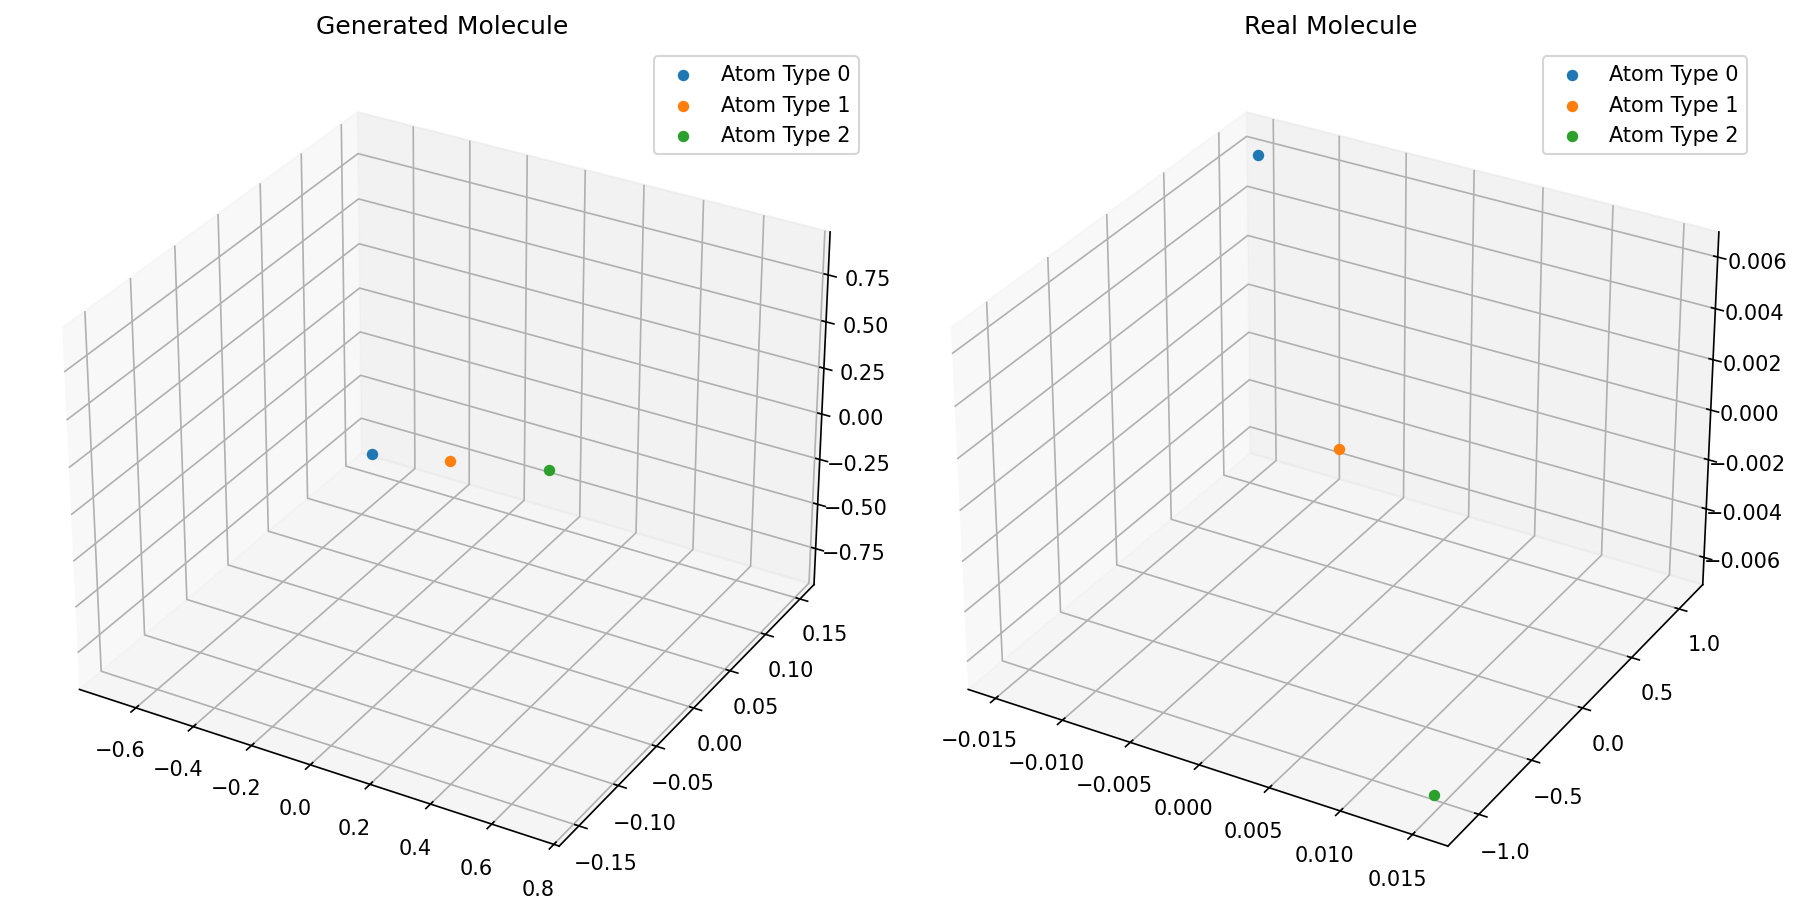

In [46]:
visualize_both_molecules_with_atom_types(
    gen_pos_test,
    gen_types_test,
    real_pos_test,
    real_types_test,
    mol_idx=0,
)

In [47]:
assignment, R, aligned_gen_pos, aligned_gen_types = find_rotation_and_permutation(gen_pos_test, real_pos_test, gen_types_test, real_types_test, sigma=1.0, eps=1e-8, max_iter=100)

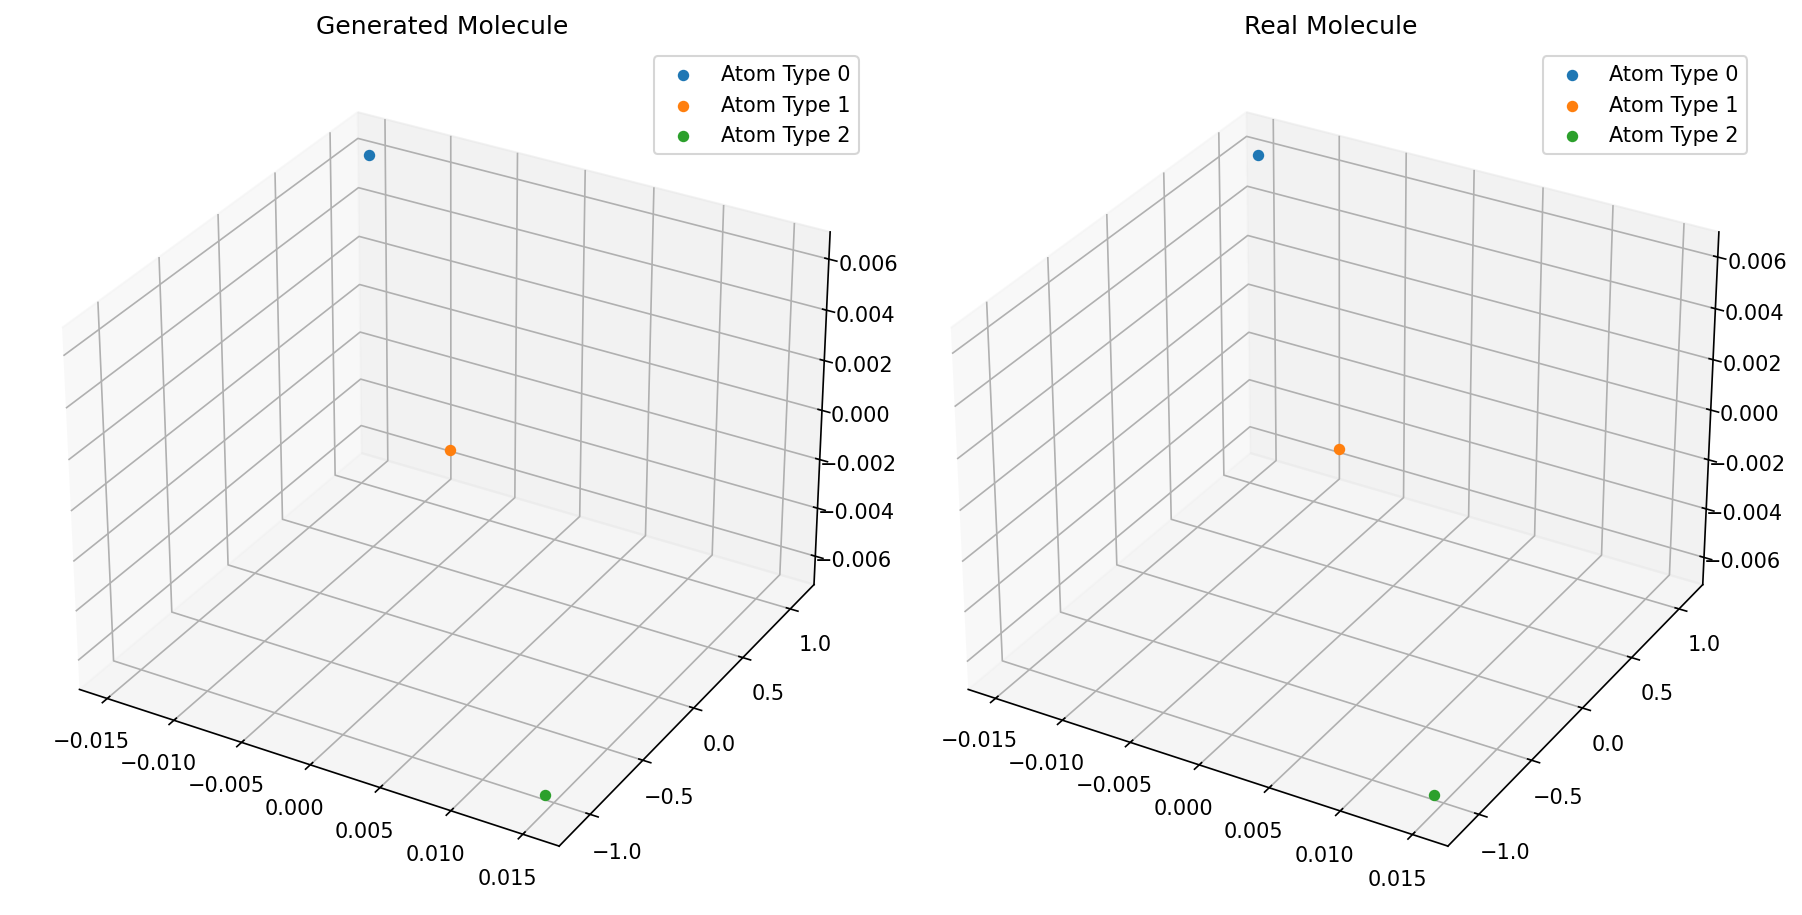

In [48]:
aligned_gen_pos = aligned_gen_pos.squeeze(0)
aligned_gen_types = aligned_gen_types.squeeze(0)

visualize_both_molecules_with_atom_types(
    aligned_gen_pos,
    aligned_gen_types,
    real_pos_test,
    real_types_test,
    mol_idx=0,
)

# Test full alignment and unaligning

Real here is from the total assingnment and rotation


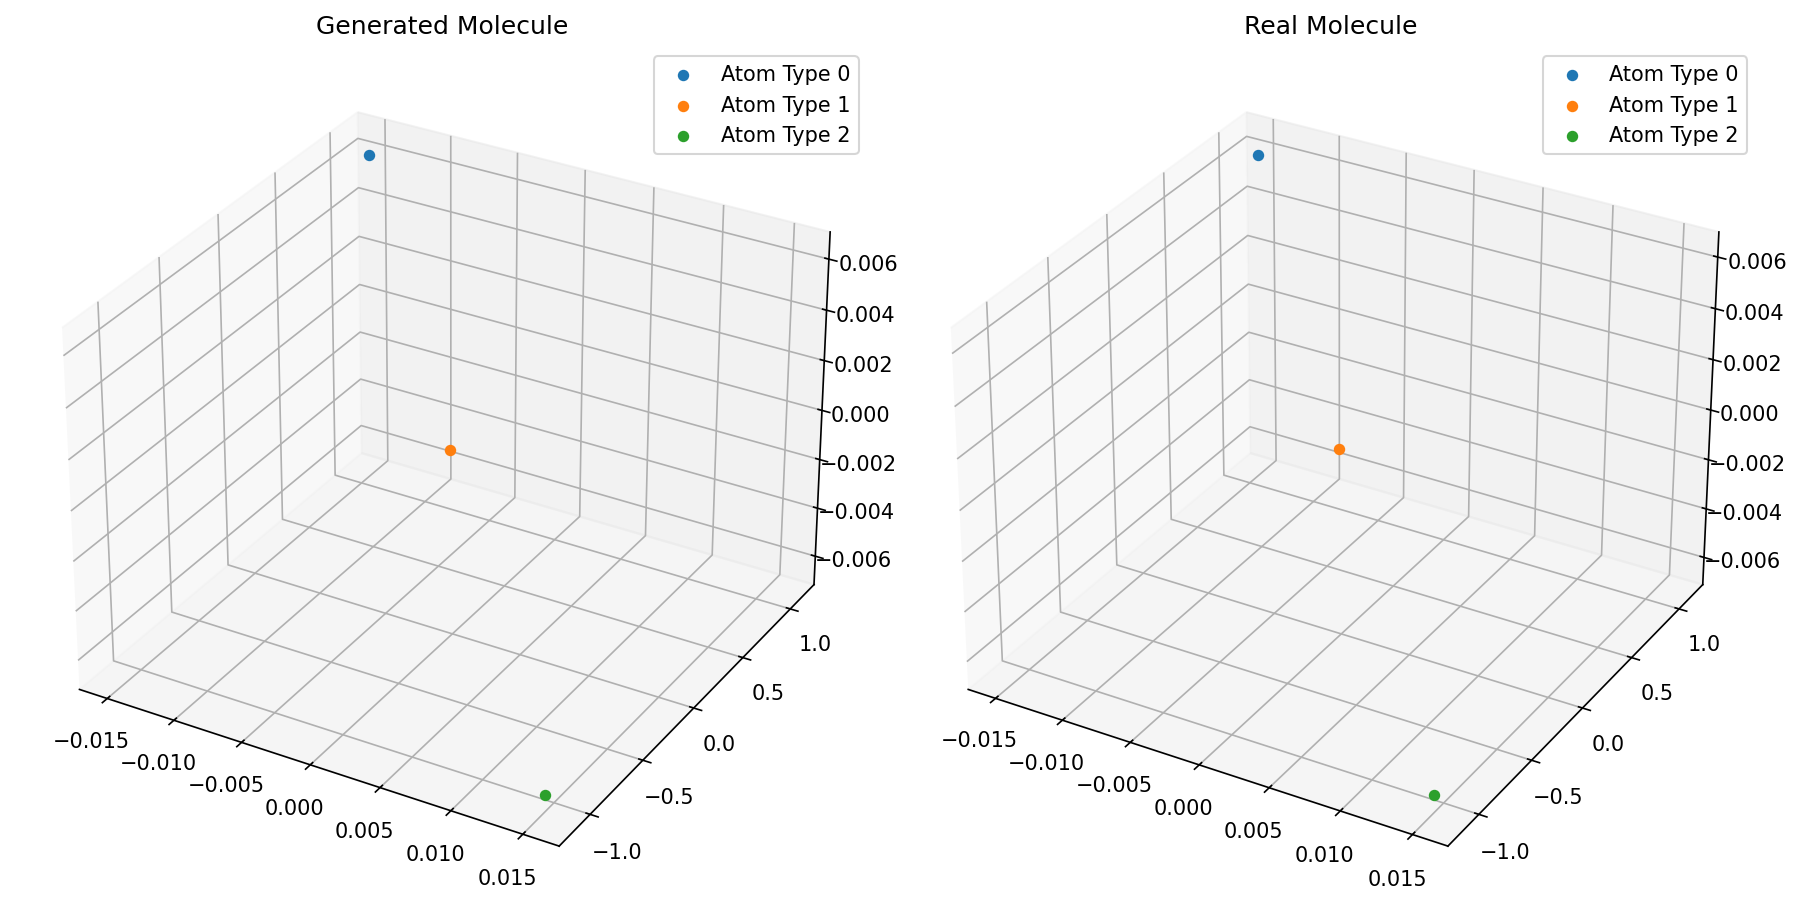

In [49]:
assignment, R, _, _ = find_rotation_and_permutation(gen_pos_test, real_pos_test, gen_types_test, real_types_test, sigma=1.0, eps=1e-8, max_iter=100)

g_pos_from_total = permute_generated_to_real_order(
    gen_pos_test.detach(),
    assignment,
)

g_types_from_total = permute_generated_to_real_order(gen_types_test, assignment)

g_pos_from_total = apply_pairwise_rotation(
    g_pos_from_total,
    R,
)

g_types_from_total = g_types_from_total.squeeze(0)
g_pos_from_total = g_pos_from_total.squeeze(0)

print("Real here is from the total assingnment and rotation")
visualize_both_molecules_with_atom_types(
    g_pos_from_total,
    g_types_from_total,
    real_pos_test,
    real_types_test,
    mol_idx=0,
)

In [50]:
g_types_from_total = g_types_from_total.unsqueeze(0)
g_pos_from_total = g_pos_from_total.unsqueeze(0)

Real here is the original rotated version


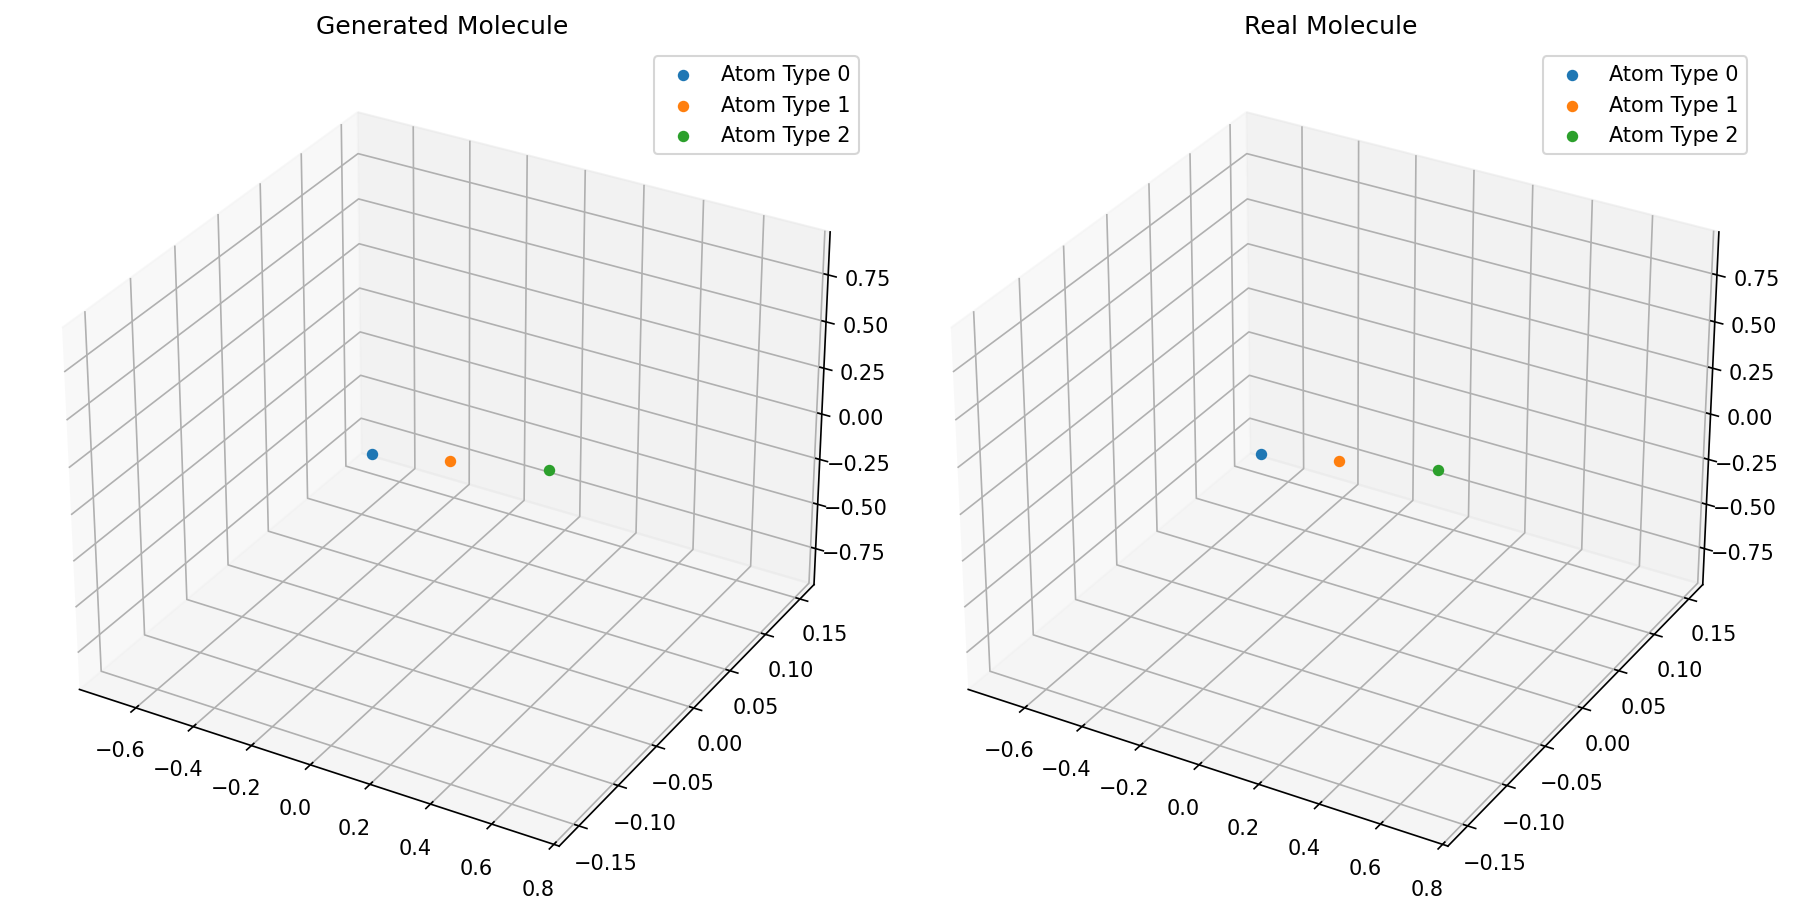

In [51]:
inv_R = R.transpose(-2, -1)
g_pos_from_total = g_pos_from_total @ inv_R
g_pos_from_total = unpermute_real_order_to_gen_order(g_pos_from_total, assignment)
g_types_from_total = unpermute_real_order_to_gen_order(g_types_from_total, assignment=assignment)

g_pos_from_total = g_pos_from_total.squeeze(0)
g_types_from_total = g_types_from_total.squeeze(0)

print("Real here is the original rotated version")
visualize_both_molecules_with_atom_types(
    g_pos_from_total,
    g_types_from_total,
    gen_pos_test,
    gen_types_test,
    mol_idx=0,
)

Works!


# For multiple:

In [52]:
indices = []
for i in range(2000):
    if dataset[i].num_nodes == 5:
        indices.append(i)
print(len(indices))

5


In [53]:
mol_indices = indices

real_pos_list = []
real_types_list = []
gen_pos_list = []
gen_types_list = []
perms = []
R_trues = []

torch.manual_seed(0)

for idx in mol_indices:
    mol = dataset[idx]

    mol_pos = mol.pos.float()
    mol_types = mol.real_atom_types.float()
    N_atoms = mol.num_nodes

    mol_pos = mol_pos - mol_pos.mean(dim=0, keepdim=True)

    # Random permutation
    perm = torch.randperm(N_atoms, device=mol_pos.device)

    # Random proper rotation matrix, det(R) = +1
    A = torch.randn(3, 3, device=mol_pos.device, dtype=mol_pos.dtype)
    Q, _ = torch.linalg.qr(A)

    if torch.det(Q) < 0:
        Q[:, -1] *= -1

    R_true = Q

    # Create transformed/generated molecule
    gen_pos = mol_pos[perm] @ R_true
    gen_types = mol_types[perm]

    real_pos_list.append(mol_pos)
    real_types_list.append(mol_types)

    gen_pos_list.append(gen_pos)
    gen_types_list.append(gen_types)

    perms.append(perm)
    R_trues.append(R_true)

gen_pos_test = torch.stack(gen_pos_list, dim=0)        # [2, N_atoms, 3]
gen_types_test = torch.stack(gen_types_list, dim=0)    # [2, N_atoms, 5]

real_pos_test = torch.stack(real_pos_list, dim=0)      # [2, N_atoms, 3]
real_types_test = torch.stack(real_types_list, dim=0)  # [2, N_atoms, 5]

perms = torch.stack(perms, dim=0)                      # [2, N_atoms]
R_trues = torch.stack(R_trues, dim=0)                  # [2, 3, 3]

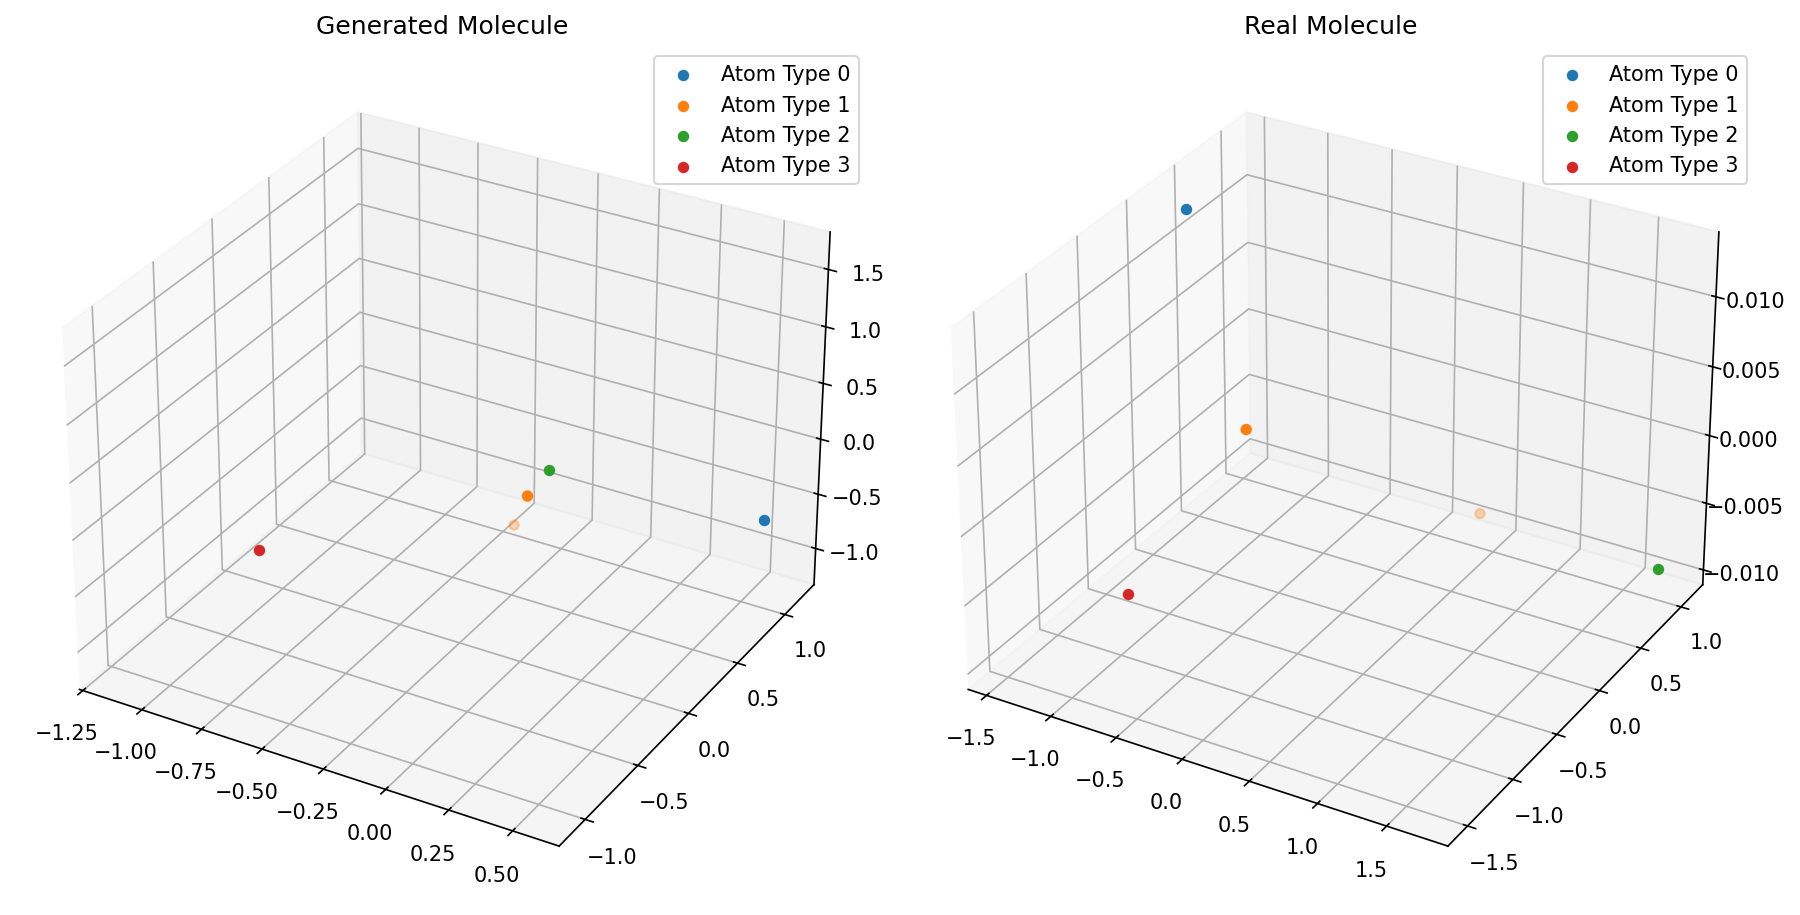

In [54]:
visualize_both_molecules_with_atom_types(
    gen_pos_test,
    gen_types_test,
    real_pos_test,
    real_types_test,
    mol_idx=2,
)

In [55]:
assignment, R, aligned_gen_pos, aligned_gen_types = find_rotation_and_permutation(gen_pos_test, real_pos_test, gen_types_test, real_types_test, sigma=1.0, eps=1e-8, max_iter=100)

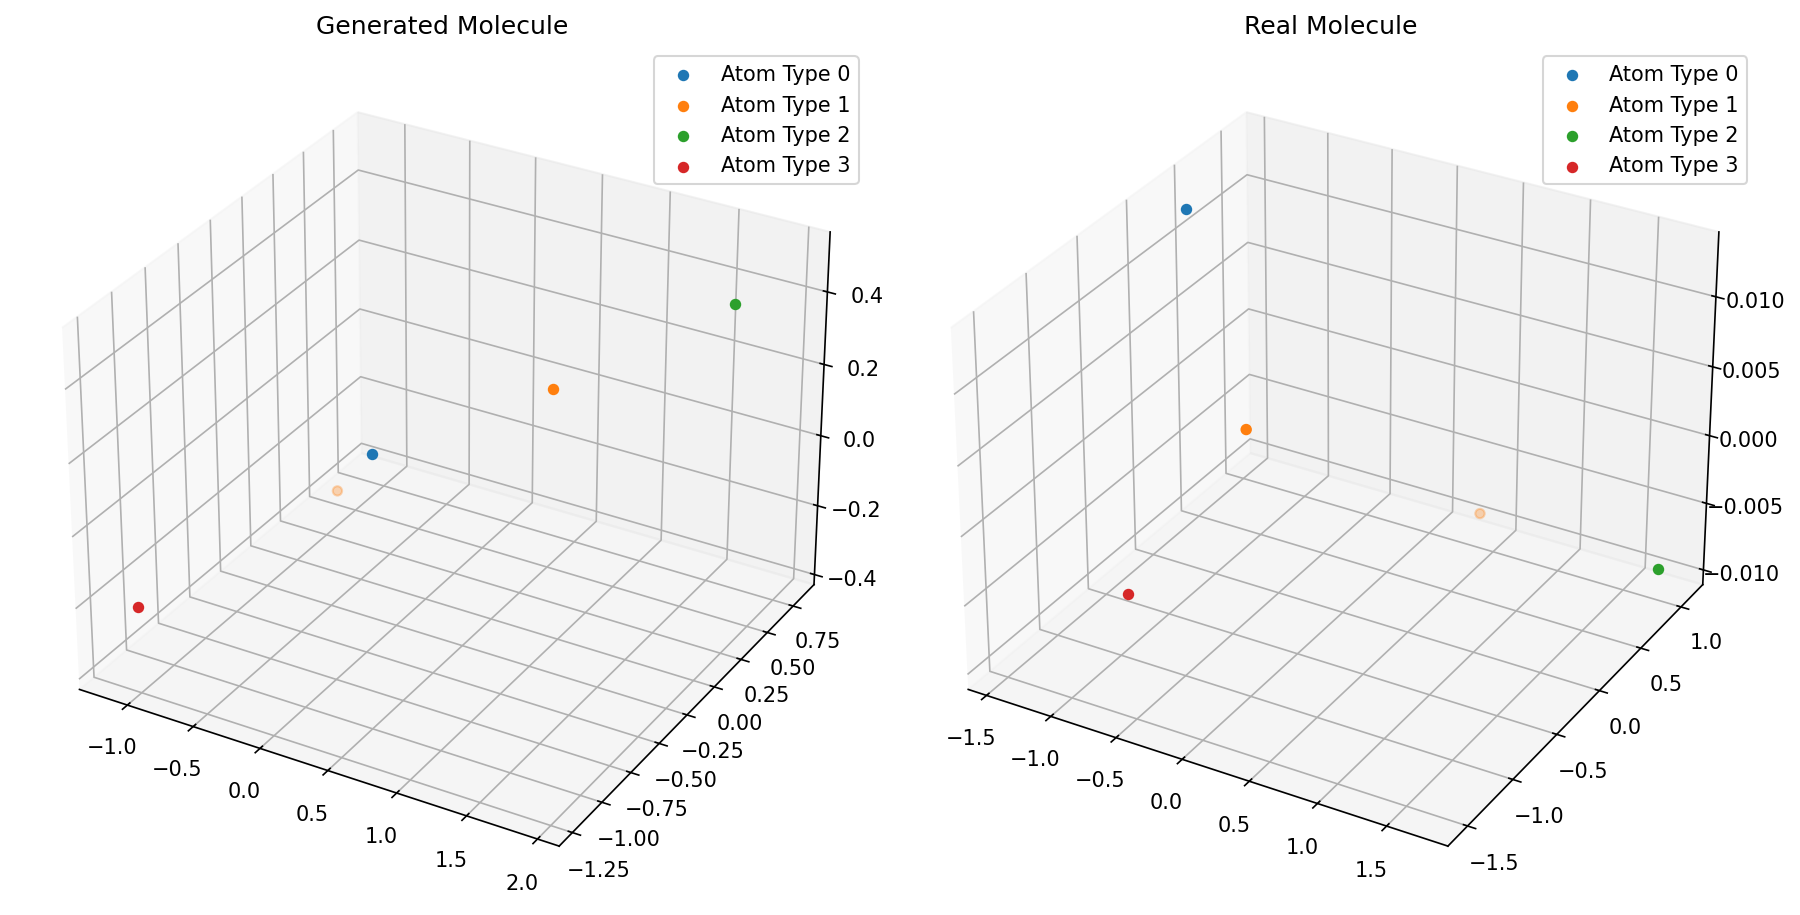

In [56]:
MOL_INDEX = 2

visualize_both_molecules_with_atom_types(
    aligned_gen_pos[:, MOL_INDEX, :, :],
    aligned_gen_types[:, MOL_INDEX, :, :],
    real_pos_test,
    real_types_test,
    mol_idx=MOL_INDEX,
)

# Test again full alignment and unaligning methods on batch

In [57]:
assignment, R, g_pos_direct, g_types_direct = find_rotation_and_permutation(gen_pos_test, real_pos_test, gen_types_test, real_types_test, sigma=1.0, eps=1e-8, max_iter=1000)

g_pos_from_total = permute_generated_to_real_order(
    gen_pos_test.detach(),
    assignment,
)

g_types_from_total = permute_generated_to_real_order(gen_types_test, assignment)

g_pos_from_total = apply_pairwise_rotation(
    g_pos_from_total,
    R,
)

real here is from full rotation and assignment


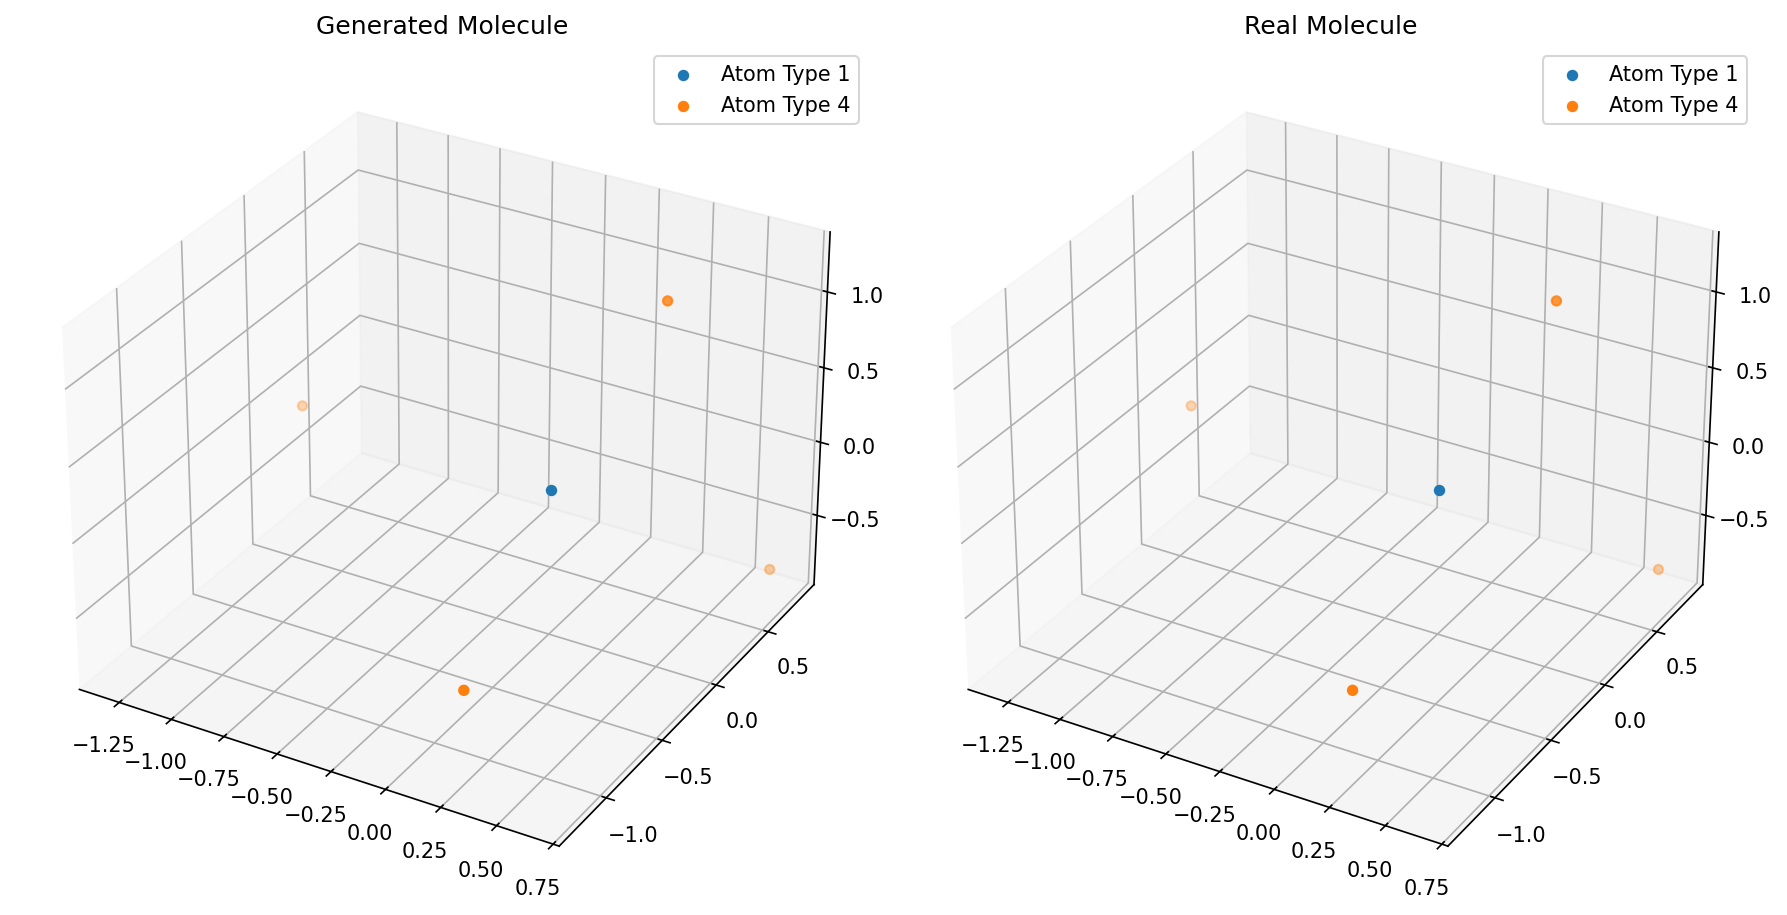

In [58]:

MOL_INDEX = 4

print("real here is from full rotation and assignment")
visualize_both_molecules_with_atom_types(
    g_pos_from_total[:, MOL_INDEX, :, :],
    g_types_from_total[:, MOL_INDEX, :, :],
    g_pos_direct[:, MOL_INDEX, :, :],
    g_types_direct[:, MOL_INDEX, :, :],
    mol_idx=MOL_INDEX,
)

In [59]:
# Testing unaligning
inv_R = R.transpose(-2, -1)
g_pos_from_total = g_pos_from_total @ inv_R
g_pos_from_total = unpermute_real_order_to_gen_order(g_pos_from_total, assignment)
g_types_from_total = unpermute_real_order_to_gen_order(g_types_from_total, assignment=assignment)

real here is from full rotation and assignment, back aligned


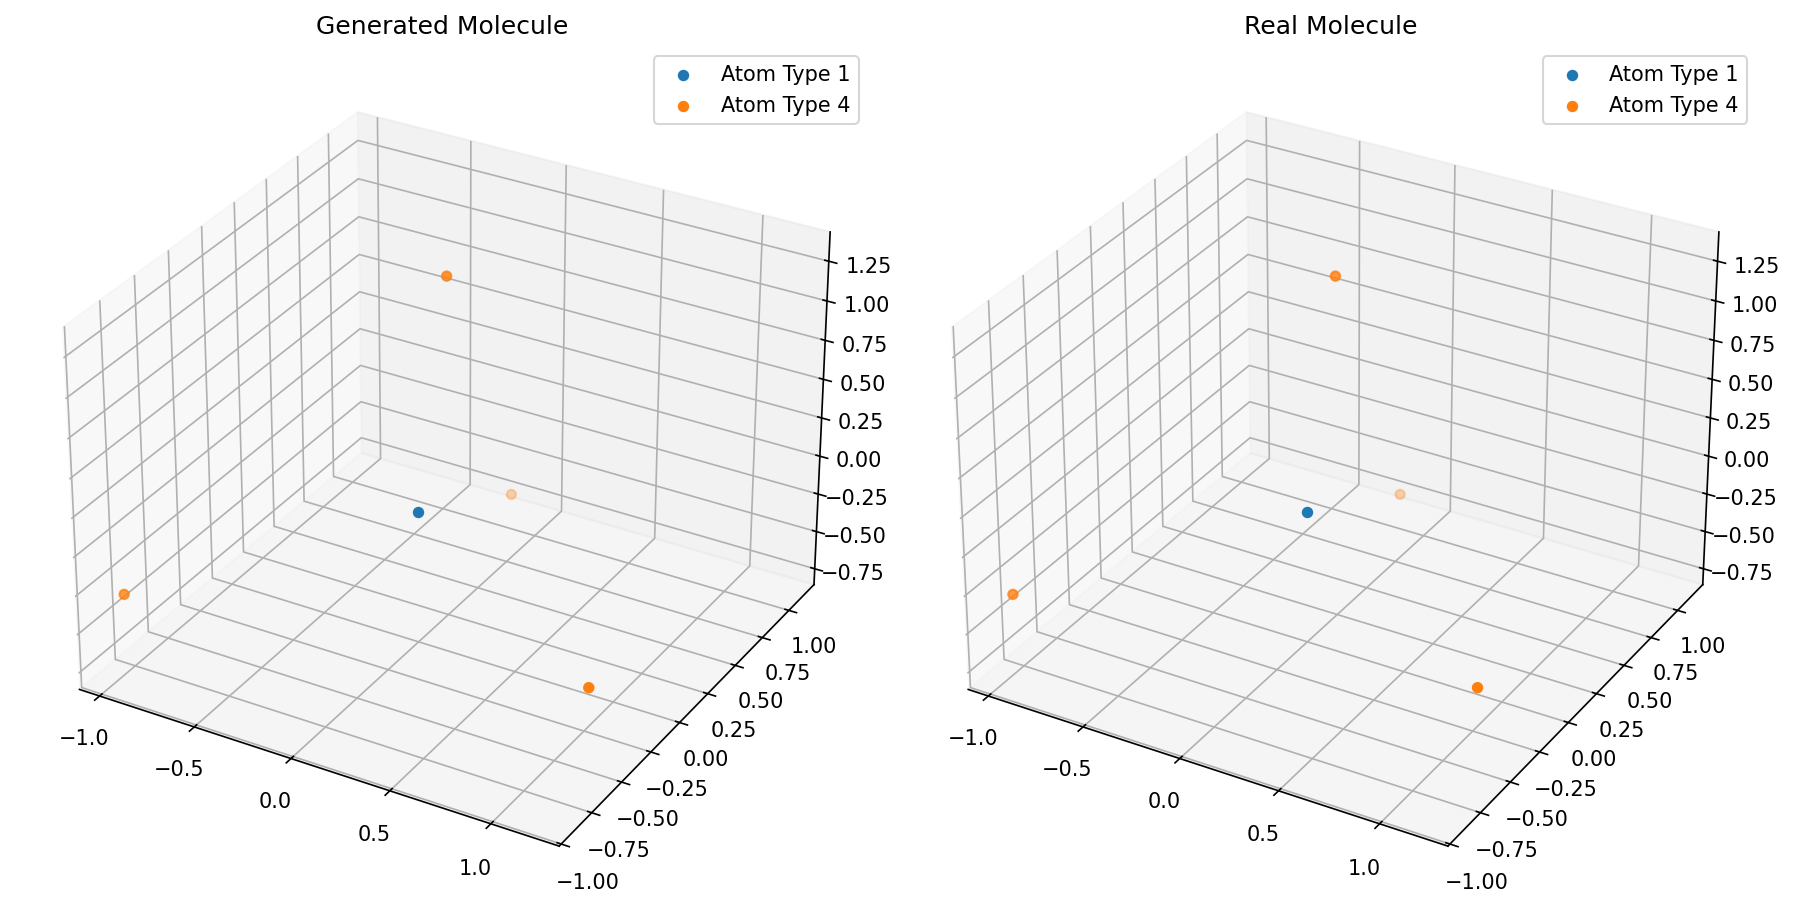

In [60]:
MOL_INDEX = 4

print("real here is from full rotation and assignment, back aligned")
visualize_both_molecules_with_atom_types(
    g_pos_from_total[:, MOL_INDEX, :, :],
    g_types_from_total[:, MOL_INDEX, :, :],
    gen_pos_test,
    gen_types_test,
    mol_idx=MOL_INDEX,
)

---

In [61]:
def compute_aligning_drift_loss(
    gen_pos: torch.Tensor,
    real_pos: torch.Tensor,
    gen_types_sphere: torch.Tensor,
    real_types: torch.Tensor,
    posit_sigma: float = 2.0,
    types_sigma: float = 1.0,
    eps: float = 1e-8,
    scale_loss: float = 1.0,
    t_eta: float = 1.0,
    p_eta: float = 1.0
) -> tuple[torch.Tensor, dict[str, float]]:
    """
    Drifting field loss directly on 3D molecules by aligning the generated molecules with the real ones.
    Assumes that x_gen_sphere is already mapped to the spherical space

    Returns (loss, stats) where stats is a flat dict of float diagnostics safe to
    pass directly to self.log(). Raises TrainingDivergedException on non-finite loss.
    """
    real_types = real_types.float()

    N_gen = gen_pos.shape[0]
    N_real = real_pos.shape[0]

    permutation_pos, R_pos, _, _ = find_rotation_and_permutation(gen_pos, real_pos, gen_types_sphere, real_types, posit_sigma, eps, max_iter=10)
    permutation_neg, R_neg, _, _ = find_rotation_and_permutation(gen_pos, gen_pos, gen_types_sphere, gen_types_sphere, posit_sigma, eps, max_iter=10)

    aligned_posit_pos = permute_generated_to_real_order(gen_pos, permutation_pos)
    aligned_types_pos = permute_generated_to_real_order(gen_types_sphere, permutation_pos)
    aligned_posit_neg = permute_generated_to_real_order(gen_pos, permutation_neg)
    aligned_types_neg = permute_generated_to_real_order(gen_types_sphere, permutation_neg)

    aligned_posit_pos = apply_pairwise_rotation(aligned_posit_pos, R_pos)
    aligned_posit_neg = apply_pairwise_rotation(aligned_posit_neg, R_neg)

    # Distances of shape [N_gen, N_real/N_gen] and Differences of shape [N_gen, N_real/N_gen, N_atoms, 3/5]
    posit_dist_pos, posit_diff_pos = _pairwise_geodesic_distance_and_log(aligned_posit_pos, real_pos, "euclidean", eps)
    posit_dist_neg, posit_diff_neg = _pairwise_geodesic_distance_and_log(aligned_posit_neg, gen_pos, "euclidean", eps)

    types_dist_pos, types_diff_pos = _pairwise_geodesic_distance_and_log(aligned_types_pos, real_types, "spherical", eps)
    types_dist_neg, types_diff_neg = _pairwise_geodesic_distance_and_log(aligned_types_neg, gen_types_sphere, "spherical", eps)

    # PERHAPS DIVIDE DIST BY SQRT N_ATOMS

    # Ignore self if y_neg is x
    eye = torch.eye(N_gen, device=gen_pos.device, dtype=torch.bool)
    posit_dist_neg = posit_dist_neg.masked_fill(eye, 1e6)
    types_dist_neg = types_dist_neg.masked_fill(eye, 1e6)
    
    # V_posit = _compute_V_at_sigma(posit_dist_pos, posit_dist_neg, posit_diff_pos, posit_diff_neg, permutation, R, posit_sigma, eps)
    # V_types = _compute_V_at_sigma(types_dist_pos, types_dist_neg, types_diff_pos, types_diff_neg, permutation, R, types_sigma, eps, euclidean=False)
    V_posit_pos = _calc_drift_direction(posit_dist_pos, posit_diff_pos, permutation_pos, R_pos, sigma=posit_sigma, eps=eps)
    V_posit_neg = _calc_drift_direction(posit_dist_neg, posit_diff_neg, permutation_neg, R_neg, sigma=posit_sigma, eps=eps)

    V_types_pos = _calc_drift_direction(types_dist_pos, types_diff_pos, permutation_pos, R_pos, sigma=types_sigma, eps=eps, euclidean=False)
    V_types_neg = _calc_drift_direction(types_dist_neg, types_diff_neg, permutation_neg, R_neg, sigma=types_sigma, eps=eps, euclidean=False)

    V_posit = V_posit_pos - V_posit_neg
    V_types = V_types_pos - V_types_neg
    V_types = sphere_project_tangent(gen_types_sphere, V_types)

    # PERHAPS HERE ADD SCALING OF DRIFTING FIELD
    V_posit = p_eta * V_posit
    V_types = t_eta * V_types

    # Calculate targets for each 
    target_posit = (gen_pos + V_posit).detach()
    target_types = sphere_exp(gen_types_sphere, V_types, eps).detach()

    # Calculate distances per molecule on each manifold
    molecule_position_dist = ((gen_pos - target_posit) ** 2).sum(dim=-1).sum(dim=-1)    # shape: [N_gen]
    molecule_types_dist = (geodesic_distance(gen_types_sphere, target_types, eps) ** 2).sum(dim=-1) # shape: [N_gen]

    loss = (molecule_position_dist + scale_loss * molecule_types_dist).mean()

    stats: dict[str, float] = {}
    with torch.no_grad():
        stats["mean_euclidean_distance"] = molecule_position_dist.mean().item()
        stats["std_euclidean_distance"] = molecule_position_dist.std().item()
        stats["mean_spherical_distance"] = molecule_types_dist.mean().item()
        stats["std_spherical_distance"] = molecule_types_dist.std().item()
        stats["norm_V_posit"] = V_posit.norm(dim=-1).mean().item()
        stats["norm_V_types"] = product_tangent_norm(V_types, eps).mean().item()
        stats["mean_V_posit_pos"] = V_posit_pos.abs().mean().item()
        stats["mean_V_posit_neg"] = V_posit_neg.abs().mean().item()
        stats["mean_V_types_pos"] = product_tangent_norm(V_types_pos, eps).mean().item()
        stats["mean_V_types_neg"] = product_tangent_norm(V_types_neg, eps).mean().item()
        stats["mean_abs_posit_dist_pos"] = posit_dist_pos.abs().mean().item()
        stats["mean_abs_posit_dist_neg"] = posit_dist_neg.abs().mean().item()
        stats["mean_abs_posit_diff_pos"] = posit_diff_pos.abs().mean().item()
        stats["mean_abs_posit_diff_neg"] = posit_diff_neg.abs().mean().item()
    
    return loss, stats


def _pairwise_geodesic_distance_and_log(
        x: torch.Tensor,
        y: torch.Tensor,
        manifold: str = "euclidean",
        eps: float = 1e-8,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Calculates the pairwise distance between atoms for the molecule attributes depending on 
    the specified geodesic distance. Assumed that molecules are aligned.
    Args:
        x: [N_x, N_y, N_atoms, z]
        y: [N_y, N_atoms, z]
    """

    if manifold == "euclidean":
        diff = x - y[None, :, :, :]                              # shape: (N_x, N_y, N_atoms, z)
        sq_dist_per_atom = (diff ** 2).sum(dim=-1)                              # shape: (N_x, N_y, N_atoms)

        sq_distances = sq_dist_per_atom.sum(dim=-1)   # shape: (N_x, N_y)
    elif manifold == "spherical":
        x = sphere_normalize(x, eps)
        y = sphere_normalize(y.unsqueeze(0), eps)

        dot = (x * y).sum(dim=-1).clamp(-1.0 + 1e-7, 1.0 - 1e-7)
        theta = torch.acos(dot)  # [N_x, N_y, N_atoms]

        sq_distances = theta.pow(2).sum(dim=-1).clamp_min(eps)  # [N_x, N_y]

        u = y - dot.unsqueeze(-1) * x  # [N_x, N_y, N_atoms, z]
        u_norm = u.norm(dim=-1, keepdim=True)

        scale = theta.unsqueeze(-1) / u_norm.clamp_min(eps)
        out = scale * u

        small = theta.unsqueeze(-1) < 1e-5
        first_order = sphere_project_tangent(x, y - x)

        out = torch.where(small, first_order, out)
        diff = sphere_project_tangent(x, out)  # shape: (N_x, N_y, N_atoms, z)
    else:
        raise ValueError("Undefined manifold.")
    return sq_distances, diff


def _calc_drift_direction(dist, diff, permutation, R, sigma, eps=1e-8, euclidean=True):
    """"
    Calculates the kernel and gradient for given distances and differences. 
    Also unaligns the gradient already!
    """
    kernel = torch.exp(-dist / (2 * sigma**2))      # shape [N_gen, N_real]
    grad_kernel = (diff * kernel.unsqueeze(-1).unsqueeze(-1)) / (sigma ** 2)    # shape [N_gen, N_real, N_atoms, D]
   
    if euclidean:
        grad_kernel = - grad_kernel
        inv_R = R.transpose(-2, -1)
        grad_kernel = grad_kernel @ inv_R

    grad_kernel = unpermute_real_order_to_gen_order(grad_kernel, permutation)

    V_dir = grad_kernel.sum(dim=1) / (kernel.sum(dim=1).clamp_min(eps).unsqueeze(-1).unsqueeze(-1)) # shape [N_gen, N_atoms, D]

    return V_dir

# Testing out on MLP

In [62]:
indices = [1, 3, 5, 24]
real_mols = dataset[indices]

real_positions = real_mols.pos.reshape(4, 4, 3)
real_types = real_mols.real_atom_types.reshape(4, 4, 5)
print(real_positions.shape)
print(real_types.shape)
real_positions = real_positions - real_positions.mean(dim=1, keepdim=True)

torch.Size([4, 4, 3])
torch.Size([4, 4, 5])


In [63]:
import torch.nn.functional as F

LR = 2e-6
ETA = 1.0

# Instantiate model and optimizer
model = DummyModel(
    num_nodes=4, num_atom_types=5
)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

TEMP = 1
NUM_ITERS = 30000

NUM_GEN = 20
    # Sample noise once but for multiple molecules
    # as the real molecules
    # This is the logic in sample noise above

loss_list = []
for iter in range(NUM_ITERS):

    pos_noise = torch.randn((NUM_GEN, 4, 3))
    pos_noise = pos_noise - pos_noise.mean(dim=1, keepdim=True)
                # We sample random noise as embedding for atom types
    type_noise = torch.randn((NUM_GEN, 4, 5))
    combined_noise = torch.cat([pos_noise, type_noise], dim=2).flatten(start_dim=1)
    optimizer.zero_grad()
    gen_mol = model(combined_noise)
    gen_mol = gen_mol.reshape(NUM_GEN, 4, -1)
    gen_pos, gen_types = torch.split(gen_mol, [3, 5], dim=-1)
    gen_pos = gen_pos - gen_pos.mean(dim=1, keepdim=True)

    gen_types_prob = F.softmax(gen_types, dim=-1)
    gen_types_sphere = probs_to_sphere(gen_types_prob, eps=1e-8)

    loss, stats = compute_aligning_drift_loss(gen_pos, real_positions, gen_types_sphere, real_types)
    
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 100 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")
        print(
            f"mean_euclidean_distance={stats['mean_euclidean_distance']:.6f}, "
            f"std_euclidean_distance={stats['std_euclidean_distance']:.6f}, "
            f"mean_spherical_distance={stats['mean_spherical_distance']:.6f}, "
            f"std_spherical_distance={stats['std_spherical_distance']:.6f}, "
            f"mean_V_posit_pos={stats['mean_V_posit_pos']:.6f}, "
            f"mean_V_posit_neg={stats['mean_V_posit_neg']:.6f}, "
            f"mean_V_types_pos={stats['mean_V_types_pos']:.6f}, "
            f"mean_V_types_neg={stats['mean_V_types_neg']:.6f}"
        )

plot_loss(loss_list)

Iter 99: Loss = 1.9991428852081299
mean_euclidean_distance=0.066152, std_euclidean_distance=0.020013, mean_spherical_distance=1.932990, std_spherical_distance=0.232787, mean_V_posit_pos=0.055555, mean_V_posit_neg=0.025911, mean_V_types_pos=0.654321, mean_V_types_neg=0.070810
Iter 199: Loss = 2.0233757495880127
mean_euclidean_distance=0.074600, std_euclidean_distance=0.033623, mean_spherical_distance=1.948776, std_spherical_distance=0.179779, mean_V_posit_pos=0.058830, mean_V_posit_neg=0.022919, mean_V_types_pos=0.657227, mean_V_types_neg=0.066183
Iter 299: Loss = 2.0188956260681152
mean_euclidean_distance=0.074011, std_euclidean_distance=0.031221, mean_spherical_distance=1.944885, std_spherical_distance=0.200545, mean_V_posit_pos=0.057517, mean_V_posit_neg=0.028615, mean_V_types_pos=0.650242, mean_V_types_neg=0.078121
Iter 399: Loss = 2.0096871852874756
mean_euclidean_distance=0.070910, std_euclidean_distance=0.028791, mean_spherical_distance=1.938777, std_spherical_distance=0.145899, 

KeyboardInterrupt: 

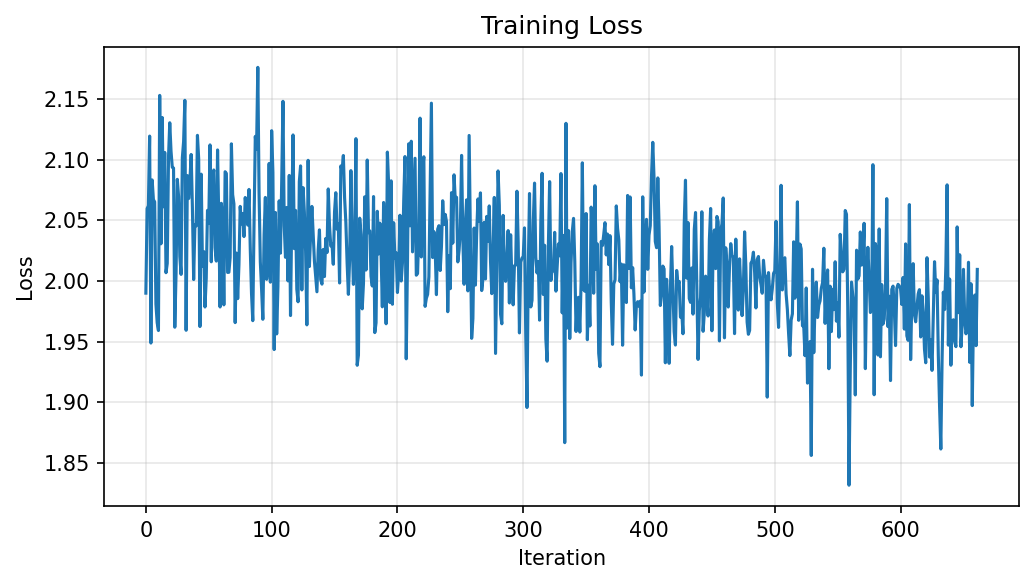

In [ ]:
plot_loss(loss_list)

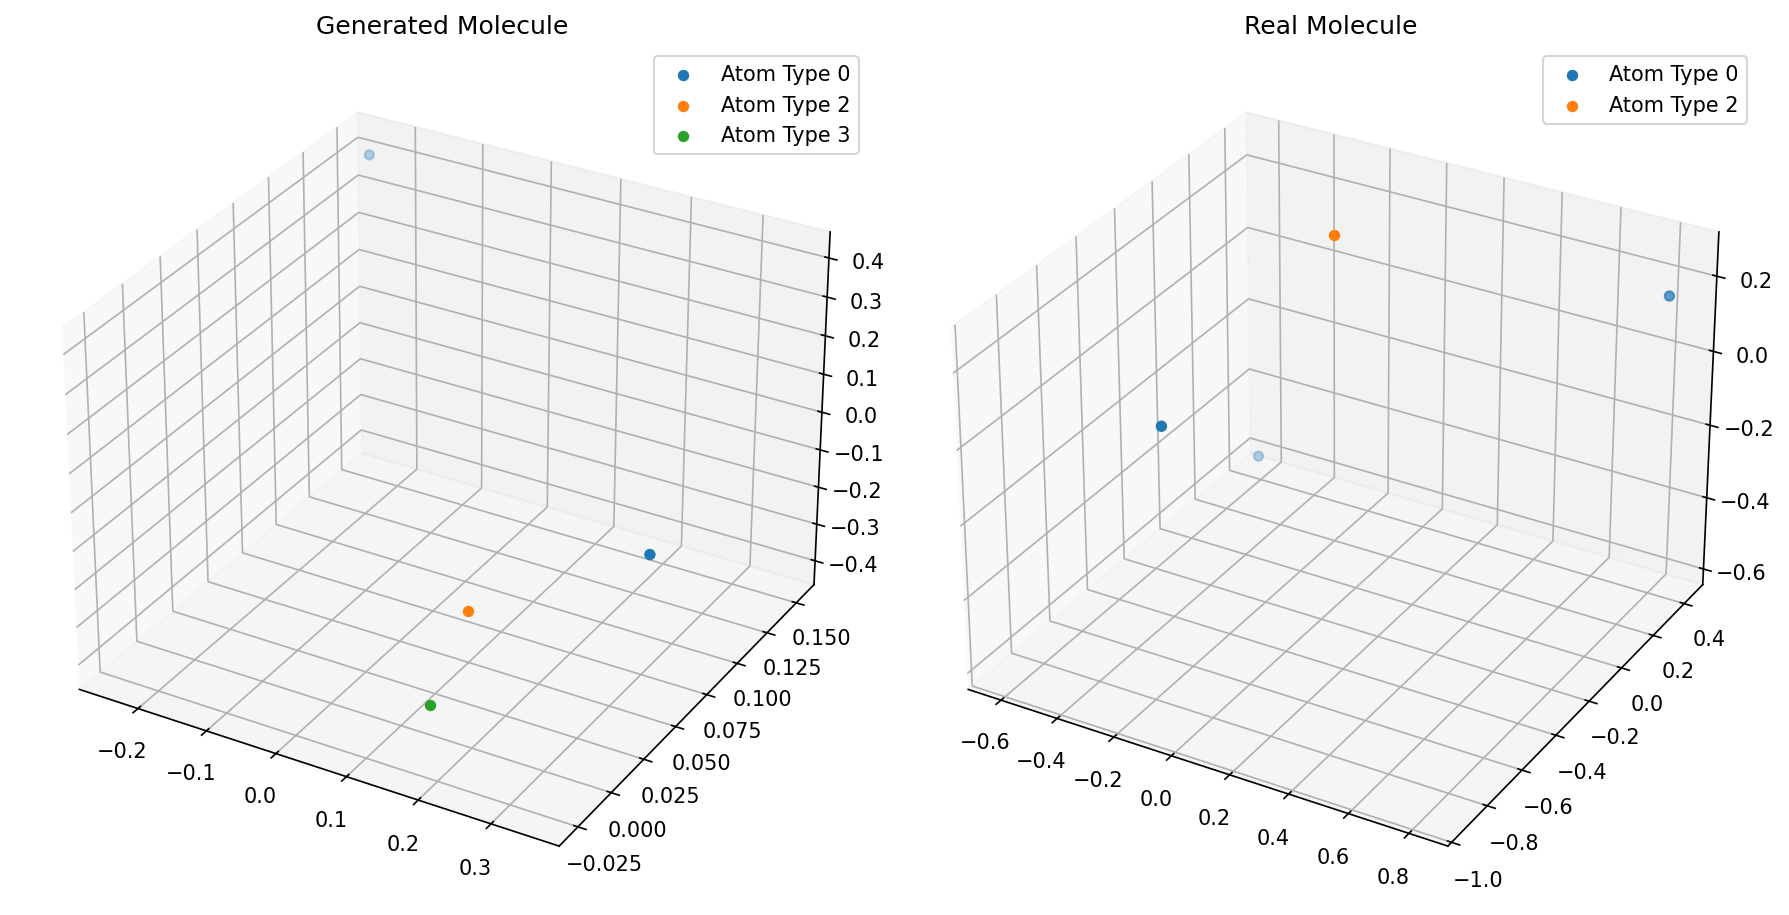

In [ ]:
NUM_GEN = 10000
pos_noise = torch.randn((NUM_GEN, 4, 3))
pos_noise = pos_noise - pos_noise.mean(dim=1, keepdim=True)
                # We sample random noise as embedding for atom types
type_noise = torch.randn((NUM_GEN, 4, 5))
combined_noise = torch.cat([pos_noise, type_noise], dim=2).flatten(start_dim=1)

gen_mol = model(combined_noise)
gen_mol = gen_mol.reshape(NUM_GEN, 4, -1)
gen_pos, gen_types = torch.split(gen_mol, [3, 5], dim=-1)
gen_types_prob = F.softmax(gen_types, dim=-1)
gen_types_sphere = probs_to_sphere(gen_types_prob, eps=1e-8)
gen_types_prob = sphere_to_probs(gen_types_sphere, eps=1e-8)

gen_types_argmax = gen_types_prob.argmax(dim=-1).float()
real_types_argmax = real_types.argmax(dim=-1).float()

# print(real_types_argmax)
# print(gen_types_argmax)

INDEX_GEN_MOL = 0

%matplotlib inline
visualize_both_molecules_with_atom_types(
    gen_pos,
    gen_types_argmax,
    real_positions,
    real_types_argmax,
    INDEX_GEN_MOL,
)

In [ ]:
evaluate_generated_molecules(gen_pos, gen_types_prob)

KeyboardInterrupt: 

# Connecting EGNN

In [64]:
import torch
from torch import nn
from torch_geometric.nn import MessagePassing

class TypeGCN(MessagePassing):
    propagate_type = {"type_feat": torch.Tensor, "edge_attr": torch.Tensor}

    def __init__(
        self, hidden_nf: int, attention: bool = True, aggr_type: str = "sum"
    ):
        super().__init__(aggr=aggr_type)

        in_message_dim = hidden_nf * 2 + 2
        self.message_mlp = nn.Sequential(
            nn.Linear(in_message_dim, in_message_dim),
            nn.SiLU(),
            nn.Linear(in_message_dim, hidden_nf),
        )

        self.update_mlp = nn.Sequential(
            nn.Linear(hidden_nf * 2, hidden_nf),
            nn.SiLU(),
            nn.Linear(hidden_nf, hidden_nf),
        )

        self.attention = attention
        if self.attention:
            self.att_mlp = nn.Sequential(
                nn.Linear(hidden_nf, 1),
                nn.Sigmoid(),
            )

    def message(
        self,
        type_feat_i: torch.Tensor,
        type_feat_j: torch.Tensor,
        edge_attr: torch.Tensor
    ) -> torch.Tensor:
        input_tensor = torch.cat(
            [type_feat_i, type_feat_j, edge_attr],
            dim=-1,
        )
        out = self.message_mlp(input_tensor)

        if self.attention:
            att_val = self.att_mlp(out)
            return out * att_val

        return out

    def update(self, aggr_out: torch.Tensor, type_feat: torch.Tensor) -> torch.Tensor:
        out = torch.cat([aggr_out, type_feat], dim=-1)
        return type_feat + self.update_mlp(out)

    def forward(
        self, type_feat: torch.Tensor, edge_index: torch.Tensor, edge_attr: torch.Tensor
    ) -> torch.Tensor:
        return self.propagate(
            edge_index, type_feat=type_feat, edge_attr=edge_attr
        )


class PosGCN(MessagePassing):
    propagate_type = {
        "type_feat": torch.Tensor,
        "scaled_dir_vector": torch.Tensor,
        "edge_attr": torch.Tensor,
    }

    def __init__(
        self,
        hidden_nf: int,
        tanh_coord_updates: bool = True,
        coords_range: float = 15.0,
        aggr_type: str = "sum",
    ):
        super().__init__(aggr=aggr_type)

        in_message_dim = hidden_nf * 2 + 2

        layer = nn.Linear(hidden_nf, 1, bias=False)
        torch.nn.init.xavier_uniform_(layer.weight, gain=0.001)

        self.coord_mlp = nn.Sequential(
            nn.Linear(in_message_dim, hidden_nf),
            nn.SiLU(),
            nn.Linear(hidden_nf, hidden_nf),
            nn.SiLU(),
            layer,
        )

        self.tanh_coord_updates = tanh_coord_updates
        self.coords_range = coords_range

    def message(
        self,
        type_feat_i: torch.Tensor,
        type_feat_j: torch.Tensor,
        edge_attr: torch.Tensor,
        scaled_dir_vector: torch.Tensor,
    ) -> torch.Tensor:
        input_tensor = torch.cat([type_feat_i, type_feat_j, edge_attr], dim=-1)
        weight = self.coord_mlp(input_tensor)
        if self.tanh_coord_updates:
            weight = torch.tanh(weight) * self.coords_range
        return scaled_dir_vector * weight

    def forward(
        self,
        pos: torch.Tensor,
        type_feat: torch.Tensor,
        edge_index: torch.Tensor,
        edge_attr: torch.Tensor,
        scaled_dir_vector: torch.Tensor,
    ) -> torch.Tensor:
        delta = self.propagate(
            edge_index,
            type_feat=type_feat,
            edge_attr=edge_attr,
            scaled_dir_vector=scaled_dir_vector,
        )
        return pos + delta


class EquivariantBlock(nn.Module):
    def __init__(
        self,
        hidden_nf: int,
        n_layers: int = 1,
        attention: bool = True,
        tanh_coord_updates: bool = True,
        coords_range: float = 15.0,
        aggr_type: str = "sum",
    ):
        super().__init__()

        self.type_update = nn.ModuleList(
            [
                TypeGCN(hidden_nf, attention=attention, aggr_type=aggr_type)
                for _ in range(n_layers)
            ]
        )

        self.coord_update = PosGCN(
            hidden_nf,
            tanh_coord_updates=tanh_coord_updates,
            coords_range=coords_range,
            aggr_type=aggr_type,
        )

    def forward(
        self,
        type_feat: torch.Tensor,
        pos: torch.Tensor,
        edge_index: torch.Tensor,
        edge_attr: torch.Tensor,
        scaled_dir_vector: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        for type_gcn in self.type_update:
            type_feat = type_gcn(
                type_feat=type_feat,
                edge_index=edge_index,
                edge_attr=edge_attr
            )

        pos = self.coord_update(
            pos=pos,
            type_feat=type_feat,
            edge_index=edge_index,
            edge_attr=edge_attr,
            scaled_dir_vector=scaled_dir_vector,
        )

        return type_feat, pos

def compute_edge_properties(
    pos: torch.Tensor, edge_index: torch.Tensor, norm_constant: float = 1.0
) -> tuple[torch.Tensor, torch.Tensor]:
    src, dst = edge_index
    dist = pos[src] - pos[dst]
    squared_norm = dist.pow(2).sum(dim=-1)
    norm = squared_norm.sqrt()
    scaled_dir_vector = dist / (norm.unsqueeze(-1) + norm_constant)
    return squared_norm, scaled_dir_vector

class EGNN(nn.Module):
    def __init__(
        self,
        num_atom_types: int,
        num_blocks: int = 9,
        hidden_nf: int = 256,
        num_layers_per_block: int = 1,
        attention: bool = True,
        tanh_coord_updates: bool = True,
        coords_range: float = 15.0,
        aggr_type: str = "sum",
    ):
        super().__init__()
        self.type_embedding = nn.Linear(num_atom_types, hidden_nf)
        self.type_embedding_out = nn.Linear(hidden_nf, num_atom_types)
        self.blocks = nn.ModuleList(
            [
                EquivariantBlock(
                    hidden_nf,
                    n_layers=num_layers_per_block,
                    attention=attention,
                    tanh_coord_updates=tanh_coord_updates,
                    coords_range=coords_range,
                    aggr_type=aggr_type,
                )
                for _ in range(num_blocks)
            ]
        )

    def forward(
        self,
        pos_noise: torch.Tensor,
        type_noise: torch.Tensor,
        edge_index: torch.Tensor,
        return_change_in_pos: bool = False,
    ) -> tuple[torch.Tensor, torch.Tensor]:

        gen_feats = self.type_embedding(type_noise)
        gen_pos = pos_noise
        initial_squared_norm, _ = compute_edge_properties(gen_pos, edge_index)

        pos_list = []
        if return_change_in_pos:
            pos_list.append(gen_pos.clone())

        for block in self.blocks:
            squared_norm, scaled_dir_vector = compute_edge_properties(gen_pos, edge_index)
            edge_attr = torch.cat(
                [initial_squared_norm.unsqueeze(-1), squared_norm.unsqueeze(-1)],
                dim=-1,
            )
            gen_feats, gen_pos = block(
                type_feat=gen_feats,
                pos=gen_pos,
                edge_index=edge_index,
                scaled_dir_vector=scaled_dir_vector,
                edge_attr=edge_attr,
            )
            if return_change_in_pos:
                pos_list.append(gen_pos.clone())

        gen_types = self.type_embedding_out(gen_feats)

        if return_change_in_pos:
            return gen_pos, gen_types, pos_list
        return gen_pos, gen_types

In [65]:
# Creating bank of noise
NOISE_BANK_SIZE = 10000
N_ATOMS = 6
POS_DIM = 3
TYPE_DIM = 5

pos_noise_bank = torch.randn(NOISE_BANK_SIZE, N_ATOMS, 3)
pos_noise_bank = pos_noise_bank - pos_noise_bank.mean(dim=0)
type_noise_bank = torch.randn(NOISE_BANK_SIZE, N_ATOMS, TYPE_DIM)

In [66]:
indices = [7, 9, 11, 22, 25, 27, 170, 172, 313, 476, 765, 813]
real_mols = dataset[indices]

real_positions = real_mols.pos.reshape(12, 6, 3)
real_types = real_mols.real_atom_types.reshape(12, 6, 5)
real_positions = real_positions - real_positions.mean(dim=1, keepdim=True)


NUM_ATOMS = 6

NUM_ATOM_TYPES = 5
NUM_BLOCKS = 5
HIDDEN_NF = 256
TANH_COORD_UPDATES = False
ATTENTION = True
AGGR_TYPE = "sum"

NUM_GEN = 20
NUM_ITERS = 7500
LR = 1e-4
P_ETA = 0.5
T_ETA = 0.7

model = EGNN(
    num_atom_types=NUM_ATOM_TYPES,
    num_blocks=NUM_BLOCKS,
    hidden_nf=HIDDEN_NF,
    attention=ATTENTION,
    tanh_coord_updates=TANH_COORD_UPDATES,
    aggr_type=AGGR_TYPE,
)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

dense_edge_index = real_mols[7].dense_edge_index
edge_index_list = []
for offset in range(NUM_GEN):
    offset_edge_index = dense_edge_index + offset * NUM_ATOMS
    edge_index_list.append(offset_edge_index)
dense_edge_index = torch.cat(edge_index_list, dim=1)

posit_sigma = 3.0

for iter in range(NUM_ITERS):
    optimizer.zero_grad()
    idx = torch.randint(0, NOISE_BANK_SIZE, (NUM_GEN, ))
    # pos_noise = torch.randn((NUM_ATOMS*NUM_GEN, 3))
    # # pos_noise = pos_noise - pos_noise.mean(dim=0)
    # type_noise = torch.randn((NUM_ATOMS*NUM_GEN, NUM_ATOM_TYPES))

    pos_noise = pos_noise_bank[idx]
    type_noise = type_noise_bank[idx]
    pos_noise = pos_noise.reshape(NUM_GEN*NUM_ATOMS, 3)
    type_noise = type_noise.reshape(NUM_GEN*NUM_ATOMS, 5)

    gen_pos, gen_types = model(pos_noise, type_noise, dense_edge_index)
   
    gen_types = gen_types.reshape(NUM_GEN, NUM_ATOMS, NUM_ATOM_TYPES)
    gen_pos = gen_pos.reshape(NUM_GEN, NUM_ATOMS, 3)
    gen_pos = gen_pos - gen_pos.mean(dim=1, keepdim=True)

    gen_types_prob = F.softmax(gen_types, dim=-1)
    gen_types_sphere = probs_to_sphere(gen_types_prob, eps=1e-8)

    # if (iter + 1) % 1500 == 0 and posit_sigma > 0.6:
    #     posit_sigma -= 0.5

    loss, stats = compute_aligning_drift_loss(gen_pos, real_positions, gen_types_sphere, real_types, p_eta=P_ETA, t_eta=T_ETA, scale_loss=1.0, posit_sigma=posit_sigma)    
    loss.backward()
    grads = [p.grad.detach().flatten() for p in model.parameters() if p.grad is not None]
    all_grads = torch.cat(grads)

    mean_abs_grad = all_grads.abs().mean()
    total_grad_norm = torch.nn.utils.clip_grad_norm_(
    model.parameters(),
    max_norm=1.0,
)
    optimizer.step()
    loss_list.append(loss.mean().item())
    
    if (iter) % 1000 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")
        print(
            f"mean_abs_grad={mean_abs_grad.item():.6f}, "
            f"total_grad_norm={total_grad_norm.item():.6f}, "
            f"mean_euclidean_distance={stats['mean_euclidean_distance']:.6f}, "
            f"std_euclidean_distance={stats['std_euclidean_distance']:.6f}, "
            f"mean_spherical_distance={stats['mean_spherical_distance']:.6f}, "
            f"std_spherical_distance={stats['std_spherical_distance']:.6f}, "
            f"norm_V_posit={stats['norm_V_posit']:.6f}, "
            f"norm_V_types={stats['norm_V_types']:.6f}, "
            f"mean_V_posit_pos={stats['mean_V_posit_pos']:.6f}, "
            f"mean_V_posit_neg={stats['mean_V_posit_neg']:.6f}, "
            f"mean_V_types_pos={stats['mean_V_types_pos']:.6f}, "
            f"mean_V_types_neg={stats['mean_V_types_neg']:.6f}, "
            f"mean_abs_posit_dist_pos={stats['mean_abs_posit_dist_pos']:.6f}, "
            f"mean_abs_posit_dist_neg={stats['mean_abs_posit_dist_neg']:.6f}, "
            f"mean_abs_posit_diff_pos={stats['mean_abs_posit_diff_pos']:.6f}, "
            f"mean_abs_posit_diff_neg={stats['mean_abs_posit_diff_neg']:.6f}"
        )

plot_loss(loss_list)

Iter 0: Loss = 0.9398143887519836
mean_abs_grad=0.000620, total_grad_norm=5.023643, mean_euclidean_distance=0.006886, std_euclidean_distance=0.002178, mean_spherical_distance=0.932929, std_spherical_distance=0.137592, norm_V_posit=0.031123, norm_V_types=0.367126, mean_V_posit_pos=0.064453, mean_V_posit_neg=0.055007, mean_V_types_pos=0.462252, mean_V_types_neg=0.113281, mean_abs_posit_dist_pos=24.610786, mean_abs_posit_dist_neg=50019.269531, mean_abs_posit_diff_pos=0.911263, mean_abs_posit_diff_neg=0.798285


KeyboardInterrupt: 

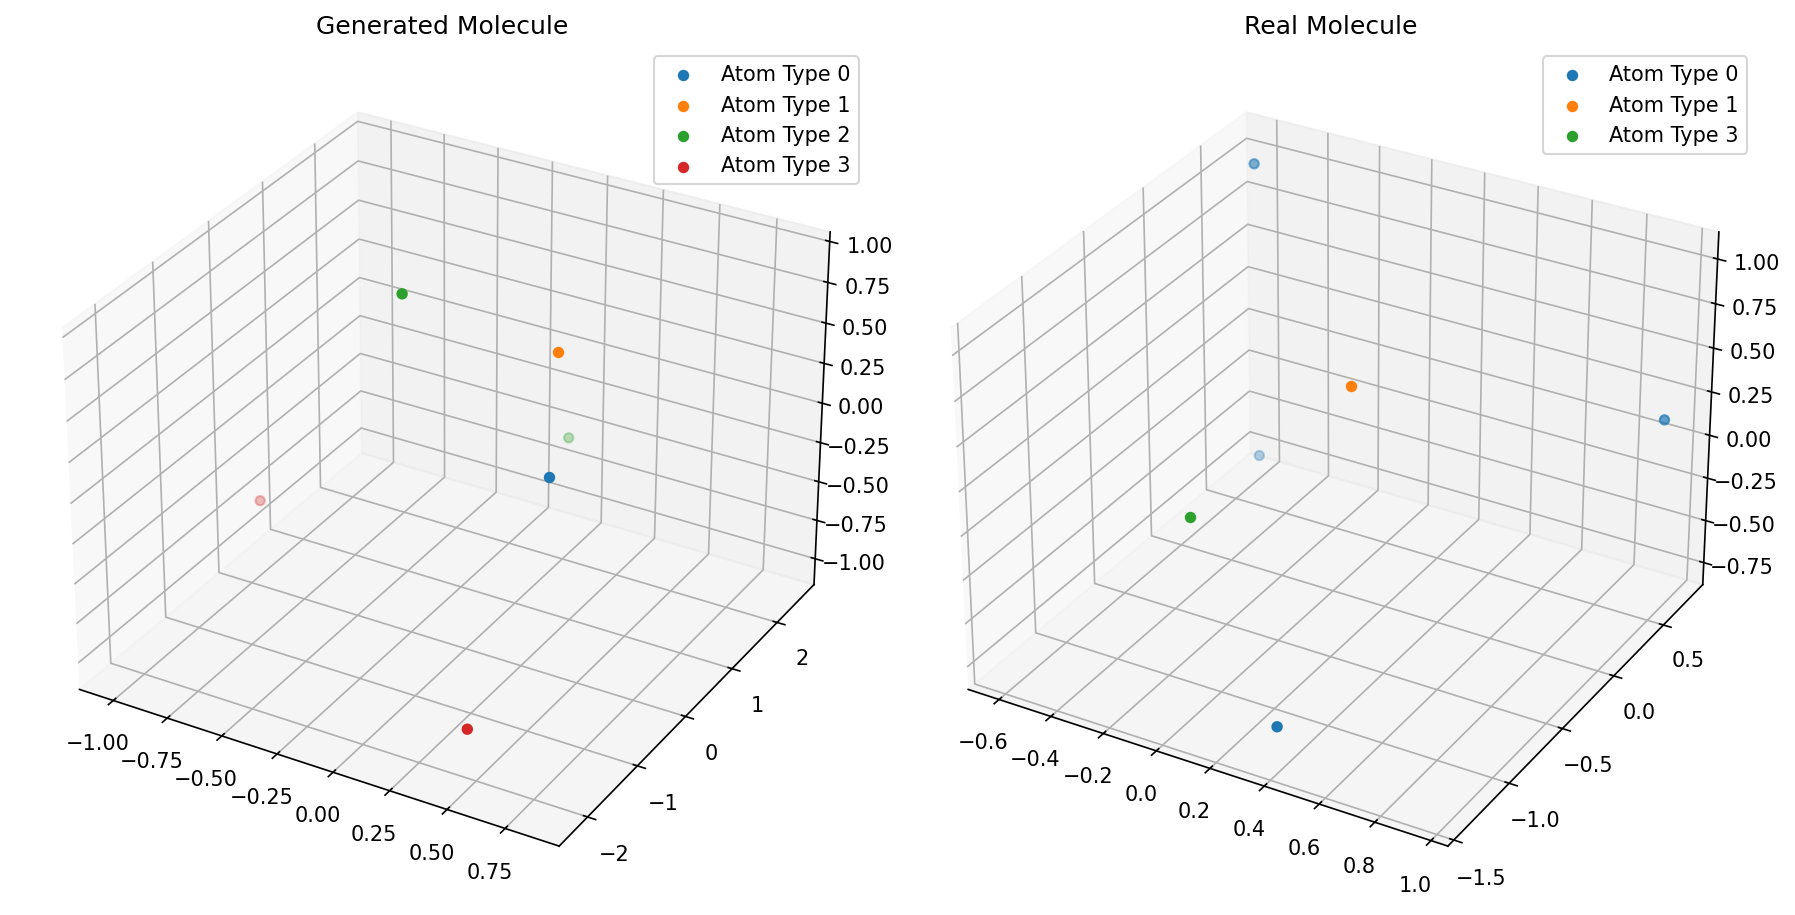

In [ ]:
dense_edge_index = real_mols[7].dense_edge_index
edge_index_list = []
for offset in range(NUM_GEN):
    offset_edge_index = dense_edge_index + offset * NUM_ATOMS
    edge_index_list.append(offset_edge_index)
dense_edge_index = torch.cat(edge_index_list, dim=1)

NUM_GEN = 1000
pos_noise = torch.randn((NUM_ATOMS*NUM_GEN, 3))
pos_noise = pos_noise - pos_noise.mean(dim=0)
type_noise = torch.randn((NUM_ATOMS*NUM_GEN, NUM_ATOM_TYPES))

gen_pos, gen_types = model(pos_noise, type_noise, dense_edge_index)

gen_types = gen_types.reshape(NUM_GEN, NUM_ATOMS, NUM_ATOM_TYPES)
gen_pos = gen_pos.reshape(NUM_GEN, NUM_ATOMS, 3)
gen_pos = gen_pos - gen_pos.mean(dim=1, keepdim=True)

gen_types_prob = F.softmax(gen_types, dim=-1)
gen_types_sphere = probs_to_sphere(gen_types_prob, eps=1e-8)
gen_types_prob = sphere_to_probs(gen_types_sphere, eps=1e-8)

gen_types_argmax = gen_types_prob.argmax(dim=-1).float()
real_types_argmax = real_types.argmax(dim=-1).float()

# print(real_types_argmax)
# print(gen_types_argmax)

INDEX_GEN_MOL = 0

%matplotlib inline
visualize_both_molecules_with_atom_types(
    gen_pos,
    gen_types_argmax,
    real_positions,
    real_types_argmax,
    INDEX_GEN_MOL,
)

In [ ]:
evaluate_generated_molecules(gen_pos, gen_types_prob)

Validity: 0.4690, Uniqueness: 0.2217, Mean Heavy Atoms: 4.87
Atom Stability Fraction: 0.1618, Molecule Stability Fraction: 0.0010


In [ ]:
from itertools import product
from pathlib import Path
import random
import time
import csv

import numpy as np
import torch
import torch.nn.functional as F

try:
    import pandas as pd
except ImportError:
    pd = None

try:
    from IPython.display import display
except ImportError:
    display = print


GRID_POS_GAMMAS = [2.0, 3.0, 4.0, 5.0, 6.0]
GRID_TYPES_GAMMAS = [0.5, 1.0, 1.5]
GRID_NUM_ITERS = 5000
GRID_TRAIN_GEN = 20
GRID_EVAL_GEN = 1000
GRID_MONITOR_GEN = 200
GRID_SEED = 0
GRID_LOG_EVERY = 1000
GRID_DEVICE = torch.device("cpu")

GRID_RESULTS_DIR = (
    Path("aligned_temperature_results")
    if Path.cwd().name == "notebooks"
    else Path("notebooks") / "aligned_temperature_results"
)
GRID_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
GRID_RESULTS_CSV = GRID_RESULTS_DIR / "aligned_loss_gamma_grid_results.csv"
GRID_HISTORY_CSV = GRID_RESULTS_DIR / "aligned_loss_gamma_grid_history.csv"


def _require_notebook_globals() -> None:
    required = [
        "EGNN",
        "compute_aligning_drift_loss",
        "probs_to_sphere",
        "batch_to_validity",
        "batch_to_stability",
        "heavy_atom_counts",
        "real_positions",
        "real_types",
        "real_mols",
        "NUM_BLOCKS",
        "HIDDEN_NF",
        "ATTENTION",
        "TANH_COORD_UPDATES",
        "AGGR_TYPE",
        "LR",
        "P_ETA",
        "T_ETA",
    ]
    missing = [name for name in required if name not in globals()]
    if missing:
        raise RuntimeError(
            "Run the setup/alignment/EGNN cells first. Missing globals: "
            + ", ".join(missing)
        )


def _set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def _dense_edge_index(base_edge_index: torch.Tensor, num_gen: int, num_atoms: int) -> torch.Tensor:
    return torch.cat(
        [base_edge_index + offset * num_atoms for offset in range(num_gen)],
        dim=1,
    )


def _base_edge_index() -> torch.Tensor:
    try:
        return real_mols[0].dense_edge_index.to(GRID_DEVICE)
    except Exception:
        return real_mols[7].dense_edge_index.to(GRID_DEVICE)


def _noise_banks(
    *,
    bank_size: int,
    num_atoms: int,
    num_atom_types: int,
    seed: int,
) -> tuple[torch.Tensor, torch.Tensor]:
    generator = torch.Generator(device="cpu").manual_seed(seed)
    pos_bank = torch.randn((bank_size, num_atoms, 3), generator=generator)
    pos_bank = pos_bank - pos_bank.mean(dim=1, keepdim=True)
    type_bank = torch.randn((bank_size, num_atoms, num_atom_types), generator=generator)
    return pos_bank.to(GRID_DEVICE), type_bank.to(GRID_DEVICE)


def _build_model(num_atom_types: int, seed: int) -> torch.nn.Module:
    _set_seed(seed)
    return EGNN(
        num_atom_types=num_atom_types,
        num_blocks=NUM_BLOCKS,
        hidden_nf=HIDDEN_NF,
        attention=ATTENTION,
        tanh_coord_updates=TANH_COORD_UPDATES,
        aggr_type=AGGR_TYPE,
    ).to(GRID_DEVICE)


def _summarize_generated_molecules(
    gen_pos: torch.Tensor,
    gen_type_probs: torch.Tensor,
) -> dict[str, float]:
    num_mol, num_atoms, _ = gen_pos.shape
    batch_vec = torch.arange(num_mol, device=gen_pos.device).repeat_interleave(num_atoms)
    hard_types = gen_type_probs.argmax(dim=-1).float()

    pos_flat = gen_pos.reshape(num_mol * num_atoms, 3).detach().cpu()
    types_flat = hard_types.reshape(num_mol * num_atoms).detach().cpu()
    batch_cpu = batch_vec.detach().cpu()

    validity_results = batch_to_validity(pos_flat, types_flat, batch_cpu)
    heavy = heavy_atom_counts(types_flat, batch_cpu)
    atom_stability, mol_stability = batch_to_stability(pos_flat, types_flat, batch_cpu)

    n_total = len(validity_results)
    n_valid = sum(1 for ok, _ in validity_results if ok)
    valid_ids = [ident for ok, ident in validity_results if ok and ident is not None]

    return {
        "validity": n_valid / n_total if n_total else 0.0,
        "uniqueness": len(set(valid_ids)) / len(valid_ids) if valid_ids else 0.0,
        "heavy_atom_mean": float(np.mean(heavy)) if heavy else 0.0,
        "atom_stability": float(atom_stability),
        "mol_stability": float(mol_stability),
    }


@torch.no_grad()
def _generate_eval_samples(
    model: torch.nn.Module,
    *,
    num_gen: int,
    num_atoms: int,
    num_atom_types: int,
    seed: int,
    base_edge_index: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor]:
    generator = torch.Generator(device="cpu").manual_seed(seed)
    pos_noise = torch.randn((num_gen, num_atoms, 3), generator=generator)
    pos_noise = pos_noise - pos_noise.mean(dim=1, keepdim=True)
    type_noise = torch.randn((num_gen, num_atoms, num_atom_types), generator=generator)

    eval_edge_index = _dense_edge_index(base_edge_index, num_gen, num_atoms)
    gen_pos, gen_types = model(
        pos_noise.reshape(num_gen * num_atoms, 3).to(GRID_DEVICE),
        type_noise.reshape(num_gen * num_atoms, num_atom_types).to(GRID_DEVICE),
        eval_edge_index,
    )

    gen_types = gen_types.reshape(num_gen, num_atoms, num_atom_types)
    gen_pos = gen_pos.reshape(num_gen, num_atoms, 3)
    gen_pos = gen_pos - gen_pos.mean(dim=1, keepdim=True)
    gen_type_probs = F.softmax(gen_types, dim=-1)
    return gen_pos, gen_type_probs


def run_single_gamma_pair(
    *,
    pos_gamma: float,
    types_gamma: float,
    seed: int,
    num_iters: int,
    num_train_gen: int,
    num_eval_gen: int,
    log_every: int,
    pos_bank: torch.Tensor,
    type_bank: torch.Tensor,
    base_edge_index: torch.Tensor,
) -> tuple[dict[str, float], list[dict[str, float]]]:
    num_atoms = real_positions.shape[1]
    num_atom_types = real_types.shape[-1]
    model = _build_model(num_atom_types, seed)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    train_edge_index = _dense_edge_index(base_edge_index, num_train_gen, num_atoms)
    real_pos_run = real_positions.to(GRID_DEVICE)
    real_types_run = real_types.to(GRID_DEVICE)
    history: list[dict[str, float]] = []
    final_stats: dict[str, float] = {}
    start = time.time()
    diverged = False
    diverged_reason = ""
    diverged_iter = None

    _set_seed(seed)
    for step in range(num_iters):
        model.train()
        optimizer.zero_grad()

        idx = torch.randint(0, pos_bank.shape[0], (num_train_gen,), device=GRID_DEVICE)
        pos_noise = pos_bank[idx].reshape(num_train_gen * num_atoms, 3)
        type_noise = type_bank[idx].reshape(num_train_gen * num_atoms, num_atom_types)

        gen_pos, gen_types = model(pos_noise, type_noise, train_edge_index)
        gen_types = gen_types.reshape(num_train_gen, num_atoms, num_atom_types)
        gen_pos = gen_pos.reshape(num_train_gen, num_atoms, 3)
        gen_pos = gen_pos - gen_pos.mean(dim=1, keepdim=True)

        if not torch.isfinite(gen_pos).all() or not torch.isfinite(gen_types).all():
            diverged = True
            diverged_iter = step + 1
            diverged_reason = "non-finite model output"
            print(f"pos={pos_gamma:g} type={types_gamma:g} diverged at iter={diverged_iter}: {diverged_reason}")
            break

        gen_type_probs = F.softmax(gen_types, dim=-1)
        gen_types_sphere = probs_to_sphere(gen_type_probs, eps=1e-8)

        if not torch.isfinite(gen_types_sphere).all():
            diverged = True
            diverged_iter = step + 1
            diverged_reason = "non-finite spherical type projection"
            print(f"pos={pos_gamma:g} type={types_gamma:g} diverged at iter={diverged_iter}: {diverged_reason}")
            break

        try:
            loss, stats = compute_aligning_drift_loss(
                gen_pos,
                real_pos_run,
                gen_types_sphere,
                real_types_run,
                p_eta=P_ETA,
                t_eta=T_ETA,
                scale_loss=1.0,
                posit_sigma=pos_gamma,
                types_sigma=types_gamma,
            )
        except (FloatingPointError, RuntimeError, ValueError) as exc:
            diverged = True
            diverged_iter = step + 1
            diverged_reason = f"{type(exc).__name__}: {exc}"
            print(f"pos={pos_gamma:g} type={types_gamma:g} diverged at iter={diverged_iter}: {diverged_reason}")
            break

        if not torch.isfinite(loss):
            diverged = True
            diverged_iter = step + 1
            diverged_reason = "non-finite loss"
            print(f"pos={pos_gamma:g} type={types_gamma:g} diverged at iter={diverged_iter}: {diverged_reason}")
            break

        loss.backward()
        total_grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        if not torch.isfinite(total_grad_norm):
            diverged = True
            diverged_iter = step + 1
            diverged_reason = "non-finite gradient norm"
            print(f"pos={pos_gamma:g} type={types_gamma:g} diverged at iter={diverged_iter}: {diverged_reason}")
            break

        optimizer.step()
        final_stats = stats

        if step == 0 or (step + 1) % log_every == 0 or step + 1 == num_iters:
            monitor_metrics = {
                "validity": float("nan"),
                "uniqueness": float("nan"),
                "heavy_atom_mean": float("nan"),
                "atom_stability": float("nan"),
                "mol_stability": float("nan"),
            }
            monitor_error = ""
            model.eval()
            try:
                monitor_pos, monitor_type_probs = _generate_eval_samples(
                    model,
                    num_gen=GRID_MONITOR_GEN,
                    num_atoms=num_atoms,
                    num_atom_types=num_atom_types,
                    seed=seed + 10_000,
                    base_edge_index=base_edge_index,
                )
                monitor_metrics = _summarize_generated_molecules(monitor_pos, monitor_type_probs)
            except Exception as exc:
                monitor_error = f"{type(exc).__name__}: {exc}"
                print(
                    f"pos={pos_gamma:g} type={types_gamma:g} monitor eval failed "
                    f"at iter={step + 1}: {monitor_error}"
                )

            valid_count = (
                int(round(monitor_metrics["validity"] * GRID_MONITOR_GEN))
                if np.isfinite(monitor_metrics["validity"])
                else None
            )
            stable_mol_count = (
                int(round(monitor_metrics["mol_stability"] * GRID_MONITOR_GEN))
                if np.isfinite(monitor_metrics["mol_stability"])
                else None
            )
            stable_atom_count = (
                int(round(monitor_metrics["atom_stability"] * GRID_MONITOR_GEN * num_atoms))
                if np.isfinite(monitor_metrics["atom_stability"])
                else None
            )

            history.append(
                {
                    "pos_gamma": float(pos_gamma),
                    "types_gamma": float(types_gamma),
                    "seed": int(seed),
                    "iter": step + 1,
                    "loss": float(loss.item()),
                    "position_dist": float(stats["mean_euclidean_distance"]),
                    "type_dist": float(stats["mean_spherical_distance"]),
                    "grad_norm": float(total_grad_norm.item()),
                    "monitor_n": int(GRID_MONITOR_GEN),
                    "validity": monitor_metrics["validity"],
                    "valid_mols": valid_count,
                    "uniqueness": monitor_metrics["uniqueness"],
                    "heavy_atom_mean": monitor_metrics["heavy_atom_mean"],
                    "atom_stability": monitor_metrics["atom_stability"],
                    "stable_atoms": stable_atom_count,
                    "mol_stability": monitor_metrics["mol_stability"],
                    "stable_mols": stable_mol_count,
                    "monitor_error": monitor_error,
                }
            )
            print(
                f"pos={pos_gamma:g} type={types_gamma:g} iter={step + 1}/{num_iters} "
                f"loss={loss.item():.5g} pos={stats['mean_euclidean_distance']:.5g} "
                f"type={stats['mean_spherical_distance']:.5g} grad={total_grad_norm.item():.5g} "
                f"valid={monitor_metrics['validity']:.3f} ({valid_count}/{GRID_MONITOR_GEN}) "
                f"mol_stab={monitor_metrics['mol_stability']:.3f} ({stable_mol_count}/{GRID_MONITOR_GEN}) "
                f"atom_stab={monitor_metrics['atom_stability']:.3f}"
            )

    if diverged:
        metrics = {
            "validity": 0.0,
            "uniqueness": 0.0,
            "heavy_atom_mean": 0.0,
            "atom_stability": 0.0,
            "mol_stability": 0.0,
        }
        final_loss = history[-1]["loss"] if history else float("nan")
    else:
        model.eval()
        eval_pos, eval_type_probs = _generate_eval_samples(
            model,
            num_gen=num_eval_gen,
            num_atoms=num_atoms,
            num_atom_types=num_atom_types,
            seed=seed + 10_000,
            base_edge_index=base_edge_index,
        )
        metrics = _summarize_generated_molecules(eval_pos, eval_type_probs)
        final_loss = history[-1]["loss"] if history else float("nan")

    row = {
        "pos_gamma": float(pos_gamma),
        "types_gamma": float(types_gamma),
        "seed": int(seed),
        "iters": int(num_iters),
        "final_loss": final_loss,
        "final_position_dist": float(final_stats.get("mean_euclidean_distance", float("nan"))),
        "final_type_dist": float(final_stats.get("mean_spherical_distance", float("nan"))),
        "validity": metrics["validity"],
        "uniqueness": metrics["uniqueness"],
        "heavy_atom_mean": metrics["heavy_atom_mean"],
        "atom_stability": metrics["atom_stability"],
        "mol_stability": metrics["mol_stability"],
        "runtime_sec": time.time() - start,
        "diverged": bool(diverged),
        "diverged_iter": diverged_iter,
        "diverged_reason": diverged_reason,
    }
    return row, history


def _history_columns() -> list[str]:
    return [
        "pos_gamma",
        "types_gamma",
        "iter",
        "loss",
        "position_dist",
        "type_dist",
        "grad_norm",
        "monitor_n",
        "validity",
        "valid_mols",
        "uniqueness",
        "heavy_atom_mean",
        "atom_stability",
        "stable_atoms",
        "mol_stability",
        "stable_mols",
        "monitor_error",
    ]


def _history_table(rows: list[dict[str, float]]):
    columns = _history_columns()
    if pd is None:
        return rows
    if not rows:
        return pd.DataFrame(columns=columns)

    df = pd.DataFrame(rows)
    for column in columns:
        if column not in df.columns:
            df[column] = np.nan
    return df[columns]


def _save_history_rows_csv(rows: list[dict[str, float]]) -> None:
    if not rows:
        return
    table = _history_table(rows)
    if pd is not None:
        table.to_csv(GRID_HISTORY_CSV, index=False)
        return

    with GRID_HISTORY_CSV.open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)


def _results_table(rows: list[dict[str, float]]):
    sort_cols = ["validity", "mol_stability", "uniqueness", "atom_stability", "final_loss"]
    if pd is None:
        return sorted(
            rows,
            key=lambda r: (
                -r["validity"],
                -r["mol_stability"],
                -r["uniqueness"],
                -r["atom_stability"],
                r["final_loss"] if np.isfinite(r["final_loss"]) else float("inf"),
            ),
        )
    columns = [
        "pos_gamma",
        "types_gamma",
        "final_loss",
        "final_position_dist",
        "final_type_dist",
        "validity",
        "uniqueness",
        "heavy_atom_mean",
        "atom_stability",
        "mol_stability",
        "runtime_sec",
        "diverged",
        "diverged_iter",
        "diverged_reason",
    ]
    return pd.DataFrame(rows)[columns].sort_values(
        sort_cols,
        ascending=[False, False, False, False, True],
    )


def _save_rows_csv(table: object) -> None:
    if pd is not None:
        table.to_csv(GRID_RESULTS_CSV, index=False)
        return

    rows = table
    if not rows:
        return
    with GRID_RESULTS_CSV.open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)


def run_gamma_grid() -> tuple[object, object, dict[tuple[float, float], list[dict[str, float]]], object]:
    _require_notebook_globals()
    num_atoms = real_positions.shape[1]
    num_atom_types = real_types.shape[-1]
    base_edge_index = _base_edge_index()
    pos_bank, type_bank = _noise_banks(
        bank_size=NOISE_BANK_SIZE if "NOISE_BANK_SIZE" in globals() else 10_000,
        num_atoms=num_atoms,
        num_atom_types=num_atom_types,
        seed=GRID_SEED,
    )

    rows: list[dict[str, float]] = []
    histories: dict[tuple[float, float], list[dict[str, float]]] = {}
    all_history_rows: list[dict[str, float]] = []

    for pos_gamma, types_gamma in product(GRID_POS_GAMMAS, GRID_TYPES_GAMMAS):
        print(f"\n=== pos_gamma={pos_gamma:g}, types_gamma={types_gamma:g} ===")
        row, history = run_single_gamma_pair(
            pos_gamma=pos_gamma,
            types_gamma=types_gamma,
            seed=GRID_SEED,
            num_iters=GRID_NUM_ITERS,
            num_train_gen=GRID_TRAIN_GEN,
            num_eval_gen=GRID_EVAL_GEN,
            log_every=GRID_LOG_EVERY,
            pos_bank=pos_bank,
            type_bank=type_bank,
            base_edge_index=base_edge_index,
        )
        rows.append(row)
        histories[(float(pos_gamma), float(types_gamma))] = history
        all_history_rows.extend(history)
        table = _results_table(rows)
        _save_rows_csv(table)
        _save_history_rows_csv(all_history_rows)
        print("checkpoint history for this run:")
        display(_history_table(history))
        print("summary so far:")
        display(table)

    table = _results_table(rows)
    if pd is None:
        best = table[0]
    else:
        best = table.iloc[0]
    _save_rows_csv(table)
    _save_history_rows_csv(all_history_rows)

    print("\nBest by validity, then molecule stability, uniqueness, atom stability, final loss:")
    display(best.to_frame().T if pd is not None else best)
    print(f"\nSaved grid results to {GRID_RESULTS_CSV}")
    print(f"Saved checkpoint history to {GRID_HISTORY_CSV}")
    return table, best, histories, _history_table(all_history_rows)


grid_results, grid_best, grid_histories, grid_history = run_gamma_grid()


In [ ]:
# Train/evaluate on all QM9 molecules with exactly 7 atoms.

ATOM_COUNT = 7

indices = [i for i, mol in enumerate(dataset) if mol.num_nodes == ATOM_COUNT]
print(f"Found {len(indices)} QM9 molecules with {ATOM_COUNT} atoms.")

real_mols = dataset[indices]

real_positions = real_mols.pos.reshape(len(indices), ATOM_COUNT, 3)
real_types = real_mols.real_atom_types.reshape(len(indices), ATOM_COUNT, 5)
real_positions = real_positions - real_positions.mean(dim=1, keepdim=True)

NUM_ATOMS = ATOM_COUNT
NUM_ATOM_TYPES = 5

# Keep these model hyperparams unless you want to change capacity.
NUM_BLOCKS = 5
HIDDEN_NF = 256
TANH_COORD_UPDATES = False
ATTENTION = True
AGGR_TYPE = "sum"

# Grid-cell training settings.
NOISE_BANK_SIZE = 10000
GRID_TRAIN_GEN = 20
GRID_EVAL_GEN = 1000
GRID_MONITOR_GEN = 200
GRID_NUM_ITERS = 5000
GRID_LOG_EVERY = 1000

LR = 1e-4
P_ETA = 0.5
T_ETA = 0.7

pos_noise_bank = torch.randn(NOISE_BANK_SIZE, NUM_ATOMS, 3)
pos_noise_bank = pos_noise_bank - pos_noise_bank.mean(dim=1, keepdim=True)
type_noise_bank = torch.randn(NOISE_BANK_SIZE, NUM_ATOMS, NUM_ATOM_TYPES)

print("real_positions:", real_positions.shape)
print("real_types:", real_types.shape)
print("pos_noise_bank:", pos_noise_bank.shape)
print("type_noise_bank:", type_noise_bank.shape)

Found 20 QM9 molecules with 7 atoms.
real_positions: torch.Size([20, 7, 3])
real_types: torch.Size([20, 7, 5])
pos_noise_bank: torch.Size([10000, 7, 3])
type_noise_bank: torch.Size([10000, 7, 5])


In [ ]:
OVERNIGHT_PLANS = {
    # 4: dict(
    #     NUM_BLOCKS=4,
    #     HIDDEN_NF=192,
    #     LR=7e-5,
    #     P_ETA=0.45,
    #     T_ETA=0.50,
    #     GRID_TRAIN_GEN=48,
    #     GRID_POS_GAMMAS=[1.5, 2.0, 3.0, 4.0, 5.0],
    #     GRID_TYPES_GAMMAS=[0.5, 1.0, 1.5, ],
    # ),
    5: dict(
        NUM_BLOCKS=5,
        HIDDEN_NF=256,
        LR=6e-5,
        P_ETA=0.45,
        T_ETA=0.50,
        GRID_TRAIN_GEN=48,
        GRID_POS_GAMMAS=[2.0, 3.0, 4.0, 5.0, 6.0],
        GRID_TYPES_GAMMAS=[0.5, 1.0, 1.5],
    ),
    6: dict(
        NUM_BLOCKS=5,
        HIDDEN_NF=256,
        LR=5e-5,
        P_ETA=0.40,
        T_ETA=0.50,
        GRID_TRAIN_GEN=32,
        GRID_POS_GAMMAS=[2.0, 3.0, 4.0, 5.0, 6.0],
        GRID_TYPES_GAMMAS=[0.5, 1.0, 1.5],
    ),
    7: dict(
        NUM_BLOCKS=6,
        HIDDEN_NF=256,
        LR=4e-5,
        P_ETA=0.40,
        T_ETA=0.45,
        GRID_TRAIN_GEN=32,
        GRID_POS_GAMMAS=[3.0, 4.0, 5.0, 6.0, 7.0],
        GRID_TYPES_GAMMAS=[0.5, 1.0, 1.5, 2.0],
    ),
}

GRID_NUM_ITERS = 5000
GRID_EVAL_GEN = 1000
GRID_MONITOR_GEN = 200
GRID_LOG_EVERY = 1000
GRID_SEED = 0

TANH_COORD_UPDATES = True
ATTENTION = True
AGGR_TYPE = "sum"
NUM_ATOM_TYPES = 5

overnight_results = {}
overnight_best = {}
overnight_histories = {}

for atom_count, cfg in OVERNIGHT_PLANS.items():
    print(f"\n\n==============================")
    print(f"Starting atom_count={atom_count}")
    print(f"Config: {cfg}")
    print(f"==============================")

    indices = [i for i, mol in enumerate(dataset) if mol.num_nodes == atom_count]
    print(f"Found {len(indices)} real QM9 molecules with {atom_count} atoms.")

    real_mols = dataset[indices]
    real_positions = real_mols.pos.reshape(len(indices), atom_count, 3)
    real_types = real_mols.real_atom_types.reshape(len(indices), atom_count, 5)
    real_positions = real_positions - real_positions.mean(dim=1, keepdim=True)

    NUM_ATOMS = atom_count
    NUM_BLOCKS = cfg["NUM_BLOCKS"]
    HIDDEN_NF = cfg["HIDDEN_NF"]
    LR = cfg["LR"]
    P_ETA = cfg["P_ETA"]
    T_ETA = cfg["T_ETA"]
    GRID_TRAIN_GEN = cfg["GRID_TRAIN_GEN"]
    GRID_POS_GAMMAS = cfg["GRID_POS_GAMMAS"]
    GRID_TYPES_GAMMAS = cfg["GRID_TYPES_GAMMAS"]

    GRID_RESULTS_CSV = GRID_RESULTS_DIR / f"aligned_loss_atoms{atom_count}_gamma_grid_results.csv"
    GRID_HISTORY_CSV = GRID_RESULTS_DIR / f"aligned_loss_atoms{atom_count}_gamma_grid_history.csv"

    grid_results, grid_best, grid_histories, grid_history = run_gamma_grid()

    overnight_results[atom_count] = grid_results
    overnight_best[atom_count] = grid_best
    overnight_histories[atom_count] = grid_history

    print(f"\nFinished atom_count={atom_count}")
    print(f"Saved summary to {GRID_RESULTS_CSV}")
    print(f"Saved history to {GRID_HISTORY_CSV}")
    display(grid_best.to_frame().T if hasattr(grid_best, "to_frame") else grid_best)

print("\nAll overnight runs finished.")
display(overnight_best)



Starting atom_count=5
Config: {'NUM_BLOCKS': 5, 'HIDDEN_NF': 256, 'LR': 6e-05, 'P_ETA': 0.45, 'T_ETA': 0.5, 'GRID_TRAIN_GEN': 48, 'GRID_POS_GAMMAS': [2.0, 3.0, 4.0, 5.0, 6.0], 'GRID_TYPES_GAMMAS': [0.5, 1.0, 1.5]}
Found 5 real QM9 molecules with 5 atoms.

=== pos_gamma=2, types_gamma=0.5 ===
pos=2 type=0.5 iter=1/5000 loss=7.1174 pos=0.023929 type=7.0935 grad=10.623 valid=0.635 (127/200) mol_stab=0.000 (0/200) atom_stab=0.241
pos=2 type=0.5 iter=1000/5000 loss=0.062334 pos=0.046019 type=0.016315 grad=44.183 valid=1.000 (200/200) mol_stab=0.000 (0/200) atom_stab=0.008
pos=2 type=0.5 iter=2000/5000 loss=0.031775 pos=0.031418 type=0.000357 grad=6.2788 valid=0.875 (175/200) mol_stab=0.000 (0/200) atom_stab=0.050
pos=2 type=0.5 iter=3000/5000 loss=0.056069 pos=0.032803 type=0.023266 grad=16.853 valid=0.980 (196/200) mol_stab=0.000 (0/200) atom_stab=0.019
pos=2 type=0.5 iter=4000/5000 loss=0.032218 pos=0.032212 type=6.0995e-06 grad=34.21 valid=0.915 (183/200) mol_stab=0.000 (0/200) atom_st

,pos_gamma,types_gamma,iter,loss,position_dist,type_dist,grad_norm,monitor_n,validity,valid_mols,uniqueness,heavy_atom_mean,atom_stability,stable_atoms,mol_stability,stable_mols,monitor_error
0,2.0,0.5,1,7.117384,0.023929,7.093456,10.623013,200,0.635,127,0.228346,4.18,0.241,241,0.0,0,
1,2.0,0.5,1000,0.062334,0.046019,0.016315,44.182892,200,1.000,200,0.020000,5.00,0.008,8,0.0,0,
2,2.0,0.5,2000,0.031775,0.031418,0.000357,6.278753,200,0.875,175,0.022857,5.00,0.050,50,0.0,0,
3,2.0,0.5,3000,0.056069,0.032803,0.023266,16.852654,200,0.980,196,0.020408,5.00,0.019,19,0.0,0,
4,2.0,0.5,4000,0.032218,0.032212,0.000006,34.210049,200,0.915,183,0.021858,5.00,0.035,35,0.0,0,
5,2.0,0.5,5000,0.036892,0.036747,0.000145,31.992817,200,0.945,189,0.021164,5.00,0.015,15,0.0,0,


summary so far:


,pos_gamma,types_gamma,final_loss,final_position_dist,final_type_dist,validity,uniqueness,heavy_atom_mean,atom_stability,mol_stability,runtime_sec,diverged,diverged_iter,diverged_reason
0,2.0,0.5,0.036892,0.036747,0.000145,0.943,0.005302,5.0,0.018,0.0,1006.371664,False,None,



=== pos_gamma=2, types_gamma=1 ===
pos=2 type=1 iter=1/5000 loss=0.3354 pos=0.023929 type=0.31147 grad=5.2301 valid=0.645 (129/200) mol_stab=0.000 (0/200) atom_stab=0.227
pos=2 type=1 iter=1000/5000 loss=0.074755 pos=0.021795 type=0.052961 grad=13.98 valid=0.670 (134/200) mol_stab=0.000 (0/200) atom_stab=0.056
pos=2 type=1 iter=2000/5000 loss=0.12594 pos=0.026435 type=0.099506 grad=14.502 valid=0.680 (136/200) mol_stab=0.000 (0/200) atom_stab=0.058
